# Sweep all carbonyl parameters × reaction parameters: LOGO cross validation

### Step 1: Setup, data loading, and descriptor definition (LOGO CV)

In this notebook we repeat the model/descriptor benchmarking using a
**leave-one-carbonyl-out (LOGO)** cross-validation scheme to assess
extrapolation to **unseen carbonyl compounds**.

For each descriptor of the carbonyl compound CX, we:

1. Build a dataset consisting of the four reaction parameters plus that single descriptor.
2. Use `carbonyl_nr` as the grouping variable for LOGO CV.
3. Train the same 17 regression models as in the random train/test split.
4. Later (Step 2), we will aggregate predictions across all LOGO folds to compute a 
   **pooled cross-validated R² (Q²)** and generate parity plots.

This cell sets up the environment, loads and cleans the data, and defines the set of descriptors.

In [1]:
"""
LOGO cross-validation over carbonyl descriptors.

For each descriptor, this notebook builds a dataset
[reaction parameters + one CX descriptor], performs
leave-one-carbonyl-out CV, and (in the next step) will train
the same suite of regression models and compute pooled Q² values.
"""

import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # headless plotting
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.base import clone

# Linear / Regularized
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV, BayesianRidge
# Kernel / Neighbors
from sklearn.svm import SVR, LinearSVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
# Trees / Ensembles
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
)
# Neural
from sklearn.neural_network import MLPRegressor
# Gaussian Process
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C


# --------------------------------------------------------------------
# Configuration
# --------------------------------------------------------------------
RANDOM_STATE = 42
DATASET_FILE = "dataset_r2filtered_ml.xlsx"
PARAM_FILE = "carbonyl_parameters.xlsx"
SUMMARY_CSV = "results_logo_all_models_all_descriptors.csv"
BASE_PLOTS_DIR = "plots_logo"
SHOW_PLOTS = False

Path(BASE_PLOTS_DIR).mkdir(exist_ok=True, parents=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
})

# Suppress non-critical GPR warnings
warnings.filterwarnings("ignore", message=".*divide by zero encountered in matmul.*")
warnings.filterwarnings("ignore", message=".*overflow encountered in matmul.*")
warnings.filterwarnings("ignore", message=".*invalid value encountered in matmul.*")


# --------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mae(y_true, y_pred) -> float:
    return float(mean_absolute_error(y_true, y_pred))


def sanitize(name: str) -> str:
    """Safe filename stem."""
    return re.sub(r"[^A-Za-z0-9_]+", "_", name)


def parity_plot_and_save(
    name: str,
    ytr,
    ytrp,
    yte,
    ytep,
    ylabel: str,
    outdir: str,
    r2_test: float,
    mae_test: float,
    suffix: str | None = None,
) -> None:
    """
    Per-fold parity plot mirroring the original cluster script:
    - ytr / ytrp: train targets and predictions for a LOGO fold
    - yte / ytep: held-out (test) targets and predictions for that fold
    - suffix: e.g. 'heldout=<carbonyl_nr>' for file naming / title
    """
    ytr = np.asarray(ytr)
    yte = np.asarray(yte)
    y_all = np.concatenate([ytr, yte])
    y_min, y_max = float(y_all.min()), float(y_all.max())

    fig, ax = plt.subplots(figsize=(6, 5.5))
    ax.scatter(ytr, ytrp, s=18, alpha=0.7, label="Train")
    ax.scatter(yte, ytep, s=24, alpha=0.7, label="Test")
    ax.plot([y_min, y_max], [y_min, y_max], "k--", lw=1.5, label="y = x")

    title_suffix = f" [{suffix}]" if suffix else ""
    ax.set_title(f"{name}{title_suffix} — R²(test)={r2_test:.3f}, MAE(test)={mae_test:.3f}")
    ax.set_xlabel(f"Actual {ylabel}")
    ax.set_ylabel(f"Predicted {ylabel}")
    ax.legend()
    plt.tight_layout()

    os.makedirs(outdir, exist_ok=True)
    filename = f"parity_{sanitize(name)}"
    if suffix:
        filename += f"_{sanitize(suffix)}"
    fig.savefig(
        os.path.join(outdir, f"{filename}.png"),
        dpi=300,
        bbox_inches="tight",
        transparent=True,
    )
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)


def parity_plot_and_save_logo_global(
    model_name: str,
    y_cv,
    y_cv_pred,
    ylabel: str,
    outdir: str,
    q2: float,
    mae_cv: float,
) -> None:
    """
    Global LOGO parity plot:
    - y_cv / y_cv_pred: pooled out-of-fold targets and predictions across all LOGO folds.
    """
    y_cv = np.asarray(y_cv)
    y_cv_pred = np.asarray(y_cv_pred)

    y_all = np.concatenate([y_cv, y_cv_pred])
    y_min, y_max = float(y_all.min()), float(y_all.max())

    fig, ax = plt.subplots(figsize=(6, 5.5))
    ax.scatter(y_cv, y_cv_pred, s=28, alpha=0.8, label="LOGO predictions")

    ax.plot([y_min, y_max], [y_min, y_max], "k--", lw=1.4, label="y = x")
    ax.set_title(f"{model_name} — Q²(LOGO)={q2:.3f}, MAE(cv)={mae_cv:.3f}")
    ax.set_xlabel(f"Actual {ylabel}")
    ax.set_ylabel(f"Predicted {ylabel}")
    ax.legend()
    plt.tight_layout()

    os.makedirs(outdir, exist_ok=True)
    filename = f"parity_LOGO_global_{sanitize(model_name)}.png"
    fig.savefig(
        os.path.join(outdir, filename),
        dpi=300,
        bbox_inches="tight",
        transparent=True,
    )
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)


def get_model_templates():
    """
    Return a dictionary mapping (Family, ModelName) -> un-fitted estimator.
    The families and models match those used in the train/test sweep.
    """
    templates = {}

    # Linear / Regularized (scaled)
    templates[("Linear/Regularized", "Linear Regression")] = LinearRegression()
    templates[("Linear/Regularized", "RidgeCV")] = RidgeCV(alphas=np.logspace(-6, 6, 25))
    templates[("Linear/Regularized", "LassoCV")] = LassoCV(
        alphas=np.logspace(-6, 1, 30),
        max_iter=20000,
        random_state=RANDOM_STATE,
    )
    templates[("Linear/Regularized", "ElasticNetCV")] = ElasticNetCV(
        l1_ratio=np.linspace(0.05, 0.95, 10),
        alphas=np.logspace(-6, 1, 30),
        max_iter=20000,
        random_state=RANDOM_STATE,
    )
    templates[("Linear/Regularized", "BayesianRidge")] = BayesianRidge()

    # Kernel / Neighbors (scaled)
    templates[("Kernel/Neighbors", "LinearSVR")] = LinearSVR(
        random_state=RANDOM_STATE,
        max_iter=20000,
        epsilon=0.1,
        C=1.0,
    )
    templates[("Kernel/Neighbors", "SVR_RBF")] = SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale")
    templates[("Kernel/Neighbors", "SVR_Poly3")] = SVR(
        kernel="poly",
        degree=3,
        C=1.0,
        epsilon=0.1,
        gamma="scale",
    )
    templates[("Kernel/Neighbors", "KernelRidge(RBF,alpha=1e-1)")] = KernelRidge(
        kernel="rbf",
        alpha=1e-1,
        gamma=None,
    )
    templates[("Kernel/Neighbors", "kNN(k=5,dist)")] = KNeighborsRegressor(
        n_neighbors=5,
        weights="distance",
    )

    # Tree Ensembles (unscaled)
    templates[("Tree Ensembles", "RandomForest")] = RandomForestRegressor(
        n_estimators=600,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    templates[("Tree Ensembles", "GradientBoosting")] = GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
    templates[("Tree Ensembles", "DecisionTree")] = DecisionTreeRegressor(
        random_state=RANDOM_STATE
    )
    templates[("Tree Ensembles", "ExtraTrees")] = ExtraTreesRegressor(
        n_estimators=600,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    templates[("Tree Ensembles", "HistGradientBoosting")] = HistGradientBoostingRegressor(
        random_state=RANDOM_STATE
    )

    # Neural (scaled)
    templates[("Neural", "MLP(100)")] = MLPRegressor(
        hidden_layer_sizes=(100,),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate="adaptive",
        max_iter=5000,
        early_stopping=True,
        random_state=RANDOM_STATE,
    )

    # Gaussian Process (scaled)
    gpr_kernel = C(1.0, constant_value_bounds="fixed") * (
        RBF(length_scale=1.0, length_scale_bounds="fixed")
        + WhiteKernel(noise_level=1e-2, noise_level_bounds="fixed")
    )
    templates[("Gaussian Process", "GPR_C*(RBF+White)_fixed")] = GaussianProcessRegressor(
        kernel=gpr_kernel,
        normalize_y=True,
        random_state=RANDOM_STATE,
        n_restarts_optimizer=0,
    )

    return templates


# --------------------------------------------------------------------
# Data loading and descriptor preparation
# --------------------------------------------------------------------
df_ds = pd.read_excel(DATASET_FILE)
df_params = pd.read_excel(PARAM_FILE)

# Coerce reaction columns (including k_obs) to numeric
reaction_cols_all = ["ha_pka", "pH_corr", "[nucleophile]", "[ha]tot", "k_obs"]
for c in reaction_cols_all:
    if c in df_ds.columns:
        df_ds[c] = pd.to_numeric(df_ds[c], errors="coerce")

# Drop rows with missing/invalid k_obs, enforce positivity, compute lg_k_obs
df_ds = df_ds.dropna(subset=["k_obs"]).copy()
df_ds = df_ds[df_ds["k_obs"] > 0].copy()
df_ds["lg_k_obs"] = np.log10(df_ds["k_obs"])

# Keep only reaction features that actually exist
reaction_cols = [c for c in ["ha_pka", "pH_corr", "[nucleophile]", "[ha]tot"] if c in df_ds.columns]

join_key = "carbonyl_nr"

# Coerce ALL parameter columns to numeric and keep only numeric ones for the sweep
for c in df_params.columns:
    if c != join_key:
        df_params[c] = pd.to_numeric(df_params[c], errors="coerce")

param_cols = [
    c for c in df_params.columns
    if c != join_key
    and pd.api.types.is_numeric_dtype(df_params[c])
    and df_params[c].notna().sum() > 1
]

print(f"Loaded dataset with {df_ds.shape[0]} reactions.")
print(f"Number of CX descriptors available for LOGO: {len(param_cols)}")


Loaded dataset with 6889 reactions.
Number of CX descriptors available for LOGO: 18


### Step 2: LOGO training, per-fold evaluation, pooled Q², and parity plots

In this step, we perform **leave-one-group-out (LOGO) cross-validation** for each
carbonyl descriptor. For every descriptor, the workflow involves:

1. **Build the dataset**:  
   Construct a feature matrix from the four reaction parameters plus the chosen CX descriptor.

2. **Define LOGO folds**:  
   Use `carbonyl_nr` as the group label. In each fold, all reactions for one carbonyl
   substrate are held out as the test set, and all others are used for training.

3. **Train and evaluate models per fold**:  
   For each of the 17 ML regression models, train on the training substrates and evaluate
   on the held-out substrate. For every fold, compute:
   - R², MAE, and RMSE on the training and test data,
   - and generate a **per-fold parity plot** (train vs. held-out reactions)

4. **Compute pooled LOGO performance (Q²)**:  
   For each model, concatenate all held-out predictions across folds and compute:
   - pooled Q² (cross-validated R²),
   - MAE(cv) and RMSE(cv).  
   A **global LOGO parity plot** (pooled out-of-fold predictions only) is saved for each
   descriptor–model pair.

5. **Write CSV outputs**:  
   - One **per-descriptor CSV** with per-fold metrics for all models:  
     `results_logo_each_combined_<descriptor>.csv`  
   - One **global summary CSV** with pooled Q² and aggregated metrics for all
     descriptor–model combinations:  
     `results_logo_all_models_all_descriptors.csv`

All parity plots are stored under:
`plots_logo/<descriptor>/`.

In [2]:
# Per-fold CSV pattern: one file per descriptor
PER_FOLD_PREFIX = "results_logo_each_combined_"
LOGO_RESULTS_CSV = SUMMARY_CSV  # "results_logo_all_models_all_descriptors.csv"

scaled_families = {"Linear/Regularized", "Kernel/Neighbors", "Neural", "Gaussian Process"}

logo_rows = []  # pooled Q² per (Descriptor, Model)


for param in param_cols:
    sub_params = df_params[[join_key, param]].copy()
    merged = df_ds.merge(sub_params, on=join_key, how="inner")

    feat_cols = [c for c in reaction_cols if c in merged.columns] + [param]
    merged = merged.dropna(subset=feat_cols + ["lg_k_obs"]).copy()

    if merged.shape[0] < 25:
        print(f"Skipping descriptor '{param}' (only {merged.shape[0]} usable rows)")
        continue

    X = merged[feat_cols].values
    y = merged["lg_k_obs"].values
    groups = merged[join_key].values
    target_name = "lg_k_obs"

    PLOTS_DIR = os.path.join(BASE_PLOTS_DIR, sanitize(param))

    print(
        f"Running LOGO CV for descriptor: {param}  "
        f"(n={len(y)}, n_groups={np.unique(groups).size})"
    )

    logo = LeaveOneGroupOut()
    templates = get_model_templates()

    # pooled out-of-fold predictions for Q²
    records = {}  # (Family, Model) -> {"y_true": [arrays], "y_pred": [arrays]}

    def ensure_record(family_name, model_name):
        key = (family_name, model_name)
        if key not in records:
            records[key] = {"y_true": [], "y_pred": []}
        return records[key]

    # collect per-fold rows for this descriptor only
    fold_rows_this_param = []

    # ---- LOGO CV: per-fold training, predictions, parity plots, and per-fold stats
    for tr_idx, te_idx in logo.split(X, y, groups):
        sub_name_arr = np.unique(groups[te_idx])
        assert len(sub_name_arr) == 1
        sub_name = str(sub_name_arr[0])

        print("\n" + "=" * 72)
        print(f"Leave-One-Substrate-Out — Held out: {sub_name}")
        print("=" * 72)

        X_train, X_test = X[tr_idx], X[te_idx]
        y_train, y_test = y[tr_idx], y[te_idx]

        scaler = StandardScaler().fit(X_train)

        for (family_name, model_name), tmpl in templates.items():
            model = clone(tmpl)

            if family_name in scaled_families:
                X_train_use = scaler.transform(X_train)
                X_test_use = scaler.transform(X_test)
            else:
                X_train_use = X_train
                X_test_use = X_test

            model.fit(X_train_use, y_train)
            y_test_pred = model.predict(X_test_use)
            y_train_pred = model.predict(X_train_use)

            # fold-level stats
            r2_train = r2_score(y_train, y_train_pred)
            r2_test = r2_score(y_test, y_test_pred)
            mae_train = mae(y_train, y_train_pred)
            mae_test = mae(y_test, y_test_pred)
            rmse_train = rmse(y_train, y_train_pred)
            rmse_test = rmse(y_test, y_test_pred)

            suffix = f"heldout={sub_name}"
            print(
                f"[{model_name} | {suffix}] "
                f"R2(test)={r2_test:.3f}, RMSE(test)={rmse_test:.4f}"
            )

            # per-fold parity plot (train vs held-out), like cluster script
            parity_plot_and_save(
                name=model_name,
                ytr=y_train,
                ytrp=y_train_pred,
                yte=y_test,
                ytep=y_test_pred,
                ylabel=target_name,
                outdir=PLOTS_DIR,
                r2_test=r2_test,
                mae_test=mae_test,
                suffix=suffix,
            )

            # store per-fold stats for this descriptor
            fold_rows_this_param.append({
                "Descriptor": param,
                "Family": family_name,
                "Model": model_name,
                "Heldout_Substrate": sub_name,
                "R2(train)": r2_train,
                "MAE(train)": mae_train,
                "RMSE(train)": rmse_train,
                "R2(test)": r2_test,
                "MAE(test)": mae_test,
                "RMSE(test)": rmse_test,
                "n_train": int(len(y_train)),
                "n_test": int(len(y_test)),
            })

            # accumulate for pooled Q²
            rec = ensure_record(family_name, model_name)
            rec["y_true"].append(y_test)
            rec["y_pred"].append(y_test_pred)

    # ---- Save per-fold CSV for this descriptor
    df_folds_param = pd.DataFrame(fold_rows_this_param)
    folds_file = f"{PER_FOLD_PREFIX}{sanitize(param)}.csv"
    df_folds_param.to_csv(folds_file, index=False)
    print(f"Saved per-fold LOGO results for '{param}' to: {folds_file}")

    # ---- For each model: compute pooled Q² over all held-out substrates
    n_groups = int(np.unique(groups).size)
    for (family_name, model_name), rec in records.items():
        y_true_cv = np.concatenate(rec["y_true"])
        y_pred_cv = np.concatenate(rec["y_pred"])

        q2 = r2_score(y_true_cv, y_pred_cv)
        mae_cv = mae(y_true_cv, y_pred_cv)
        rmse_cv = rmse(y_true_cv, y_pred_cv)

        # Global LOGO parity plot (pooled across all folds)
        parity_plot_and_save_logo_global(
            model_name=model_name,
            y_cv=y_true_cv,
            y_cv_pred=y_pred_cv,
            ylabel=target_name,
            outdir=PLOTS_DIR,
            q2=q2,
            mae_cv=mae_cv,
        )

        logo_rows.append({
            "Descriptor": param,
            "Family": family_name,
            "Model": model_name,
            "Q2(LOGO)": q2,
            "MAE(cv)": mae_cv,
            "RMSE(cv)": rmse_cv,
            "n_samples": int(len(y)),
            "n_groups": n_groups,
        })

# --------------------------------------------------------------------
# Save pooled LOGO metrics
# --------------------------------------------------------------------
df_logo = pd.DataFrame(logo_rows)
df_logo.to_csv(LOGO_RESULTS_CSV, index=False)
print(f"\nSaved pooled LOGO results to: {LOGO_RESULTS_CSV}")
print(f"Parity plots stored under: {BASE_PLOTS_DIR}/<Descriptor>/")

Running LOGO CV for descriptor: homo_min  (n=6889, n_groups=10)

Leave-One-Substrate-Out — Held out: C1
[Linear Regression | heldout=C1] R2(test)=-0.306, RMSE(test)=1.1954
[RidgeCV | heldout=C1] R2(test)=-0.306, RMSE(test)=1.1953
[LassoCV | heldout=C1] R2(test)=-0.294, RMSE(test)=1.1902
[ElasticNetCV | heldout=C1] R2(test)=-0.297, RMSE(test)=1.1911
[BayesianRidge | heldout=C1] R2(test)=-0.305, RMSE(test)=1.1951
[LinearSVR | heldout=C1] R2(test)=-0.235, RMSE(test)=1.1627
[SVR_RBF | heldout=C1] R2(test)=0.904, RMSE(test)=0.3240
[SVR_Poly3 | heldout=C1] R2(test)=0.008, RMSE(test)=1.0421
[KernelRidge(RBF,alpha=1e-1) | heldout=C1] R2(test)=0.917, RMSE(test)=0.3020
[kNN(k=5,dist) | heldout=C1] R2(test)=0.918, RMSE(test)=0.3002
[RandomForest | heldout=C1] R2(test)=0.931, RMSE(test)=0.2757
[GradientBoosting | heldout=C1] R2(test)=0.902, RMSE(test)=0.3271
[DecisionTree | heldout=C1] R2(test)=0.915, RMSE(test)=0.3044
[ExtraTrees | heldout=C1] R2(test)=0.920, RMSE(test)=0.2963
[HistGradientBoosti

### Step 3: Global LOGO summary and descriptor leaderboards

This step analyzes the pooled LOGO results in
`results_logo_all_models_all_descriptors.csv`. For each descriptor–model pair we
have Q²(LOGO), MAE(cv), and RMSE(cv). We:

1. Construct a **global heatmap of Q²(LOGO)** across all descriptor–model combinations.
2. Compute **descriptor leaderboards** based on Q²(LOGO):
   - over **all models**, and
   - over **“strong” models**, defined as those whose *best* descriptor achieves
     Q²(LOGO) above a chosen threshold.
3. Identify the **best descriptor per model** as the descriptor with the highest
   Q²(LOGO) for that model.

The global heatmap and leaderboards are saved to `analysis_logo/` for use in the SI.

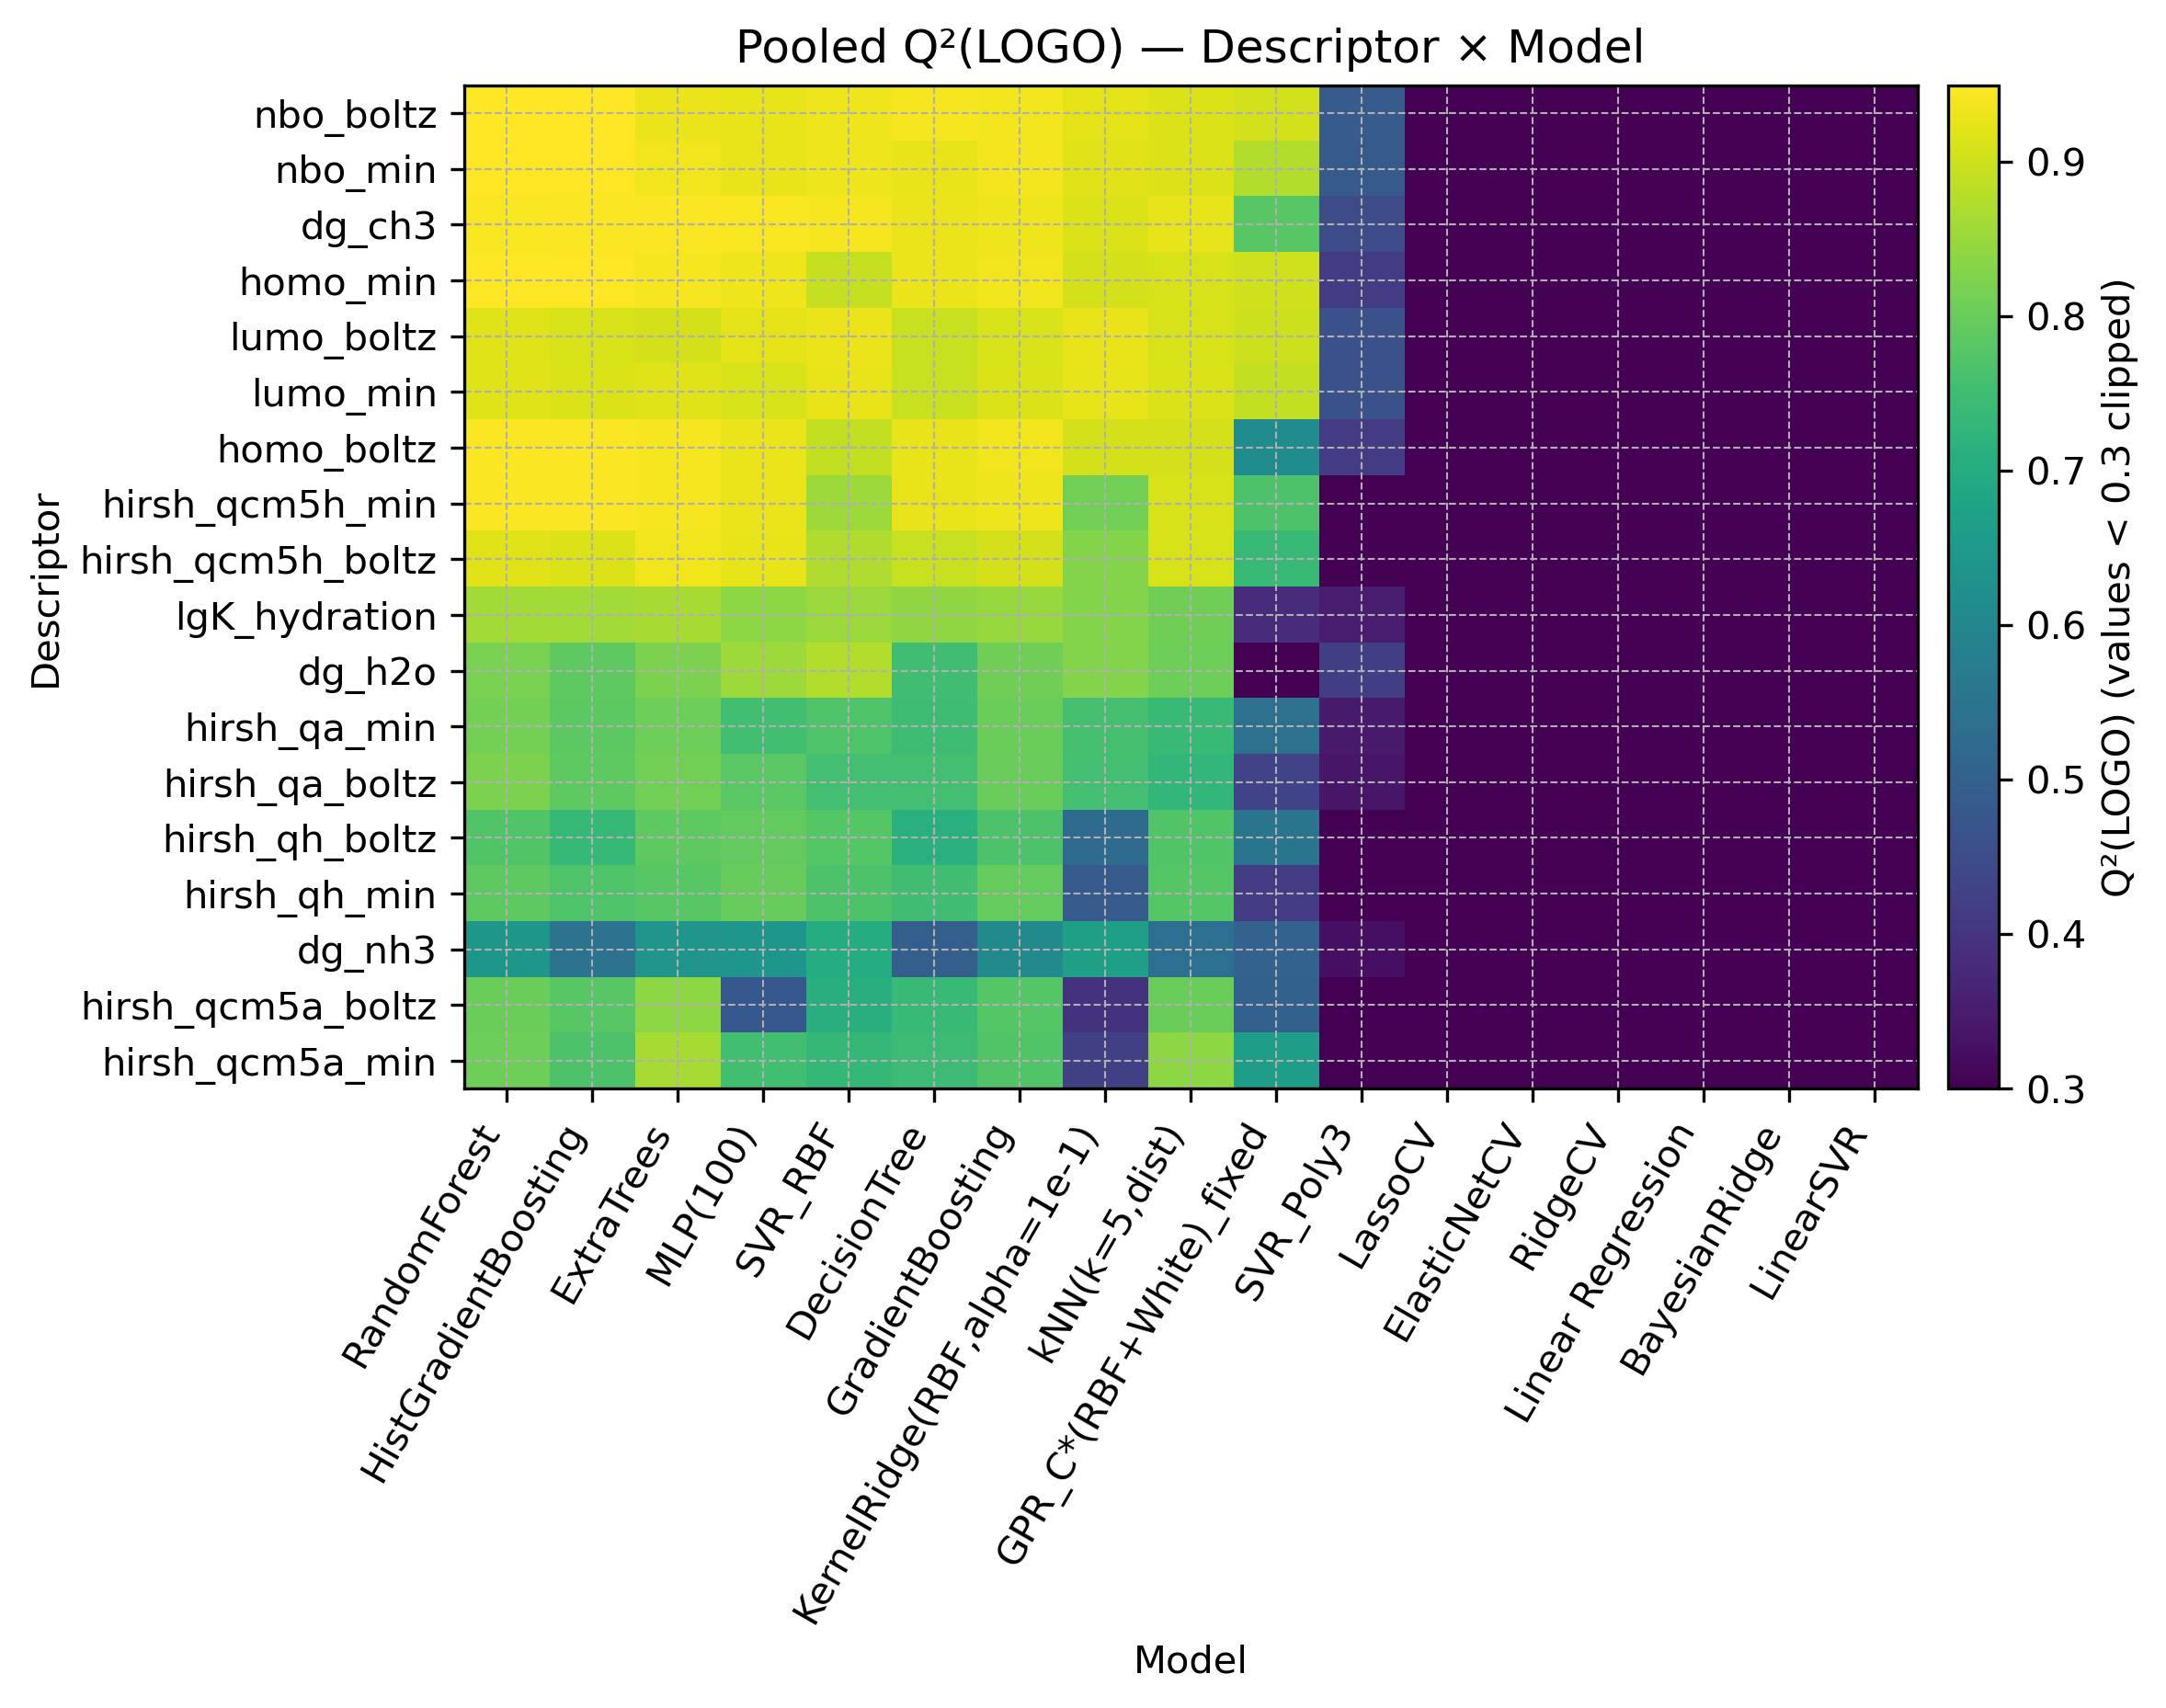

Global descriptor leaderboard (ALL models, based on Q²(LOGO)):


,Descriptor,median_Q2,mean,std,count
17,nbo_min,0.915261,0.669846,0.321178,17
16,nbo_boltz,0.914421,0.672115,0.322383,17
0,dg_ch3,0.913105,0.659703,0.326047,17
12,homo_min,0.901622,0.657052,0.332098,17
14,lumo_boltz,0.899033,0.655436,0.321008,17
15,lumo_min,0.895902,0.655070,0.320302,17
11,homo_boltz,0.889875,0.639766,0.325262,17
7,hirsh_qcm5h_boltz,0.827842,0.616402,0.334152,17
8,hirsh_qcm5h_min,0.810359,0.619705,0.346461,17
13,lgK_hydration,0.808359,0.570876,0.302926,17


Saved: analysis_logo/descriptor_leaderboard_all_models_Q2.png

Best descriptor per model (by Q²(LOGO)):


,Model,Descriptor,Family,Q2(LOGO),MAE(cv),RMSE(cv),n_samples,n_groups
12,RandomForest,nbo_boltz,Tree Ensembles,0.949422,0.185436,0.267899,6889,10
6,HistGradientBoosting,nbo_min,Tree Ensembles,0.948591,0.191270,0.270091,6889,10
3,ExtraTrees,dg_ch3,Tree Ensembles,0.946216,0.187934,0.276259,6889,10
11,MLP(100),dg_ch3,Neural,0.943872,0.212615,0.282214,6889,10
15,SVR_RBF,dg_ch3,Kernel/Neighbors,0.939413,0.211221,0.293211,6889,10
1,DecisionTree,nbo_boltz,Tree Ensembles,0.939393,0.203823,0.293259,6889,10
5,GradientBoosting,nbo_min,Tree Ensembles,0.937358,0.221149,0.298142,6889,10
7,"KernelRidge(RBF,alpha=1e-1)",lumo_boltz,Kernel/Neighbors,0.926643,0.242598,0.322633,6889,10
16,"kNN(k=5,dist)",dg_ch3,Kernel/Neighbors,0.924226,0.230301,0.327905,6889,10
4,GPR_C*(RBF+White)_fixed,nbo_boltz,Gaussian Process,0.904524,0.258955,0.368075,6889,10



Strong-model threshold: best Q²(LOGO) ≥ 0.5
Strong models (10): ['RandomForest', 'HistGradientBoosting', 'ExtraTrees', 'MLP(100)', 'SVR_RBF', 'DecisionTree', 'GradientBoosting', 'KernelRidge(RBF,alpha=1e-1)', 'kNN(k=5,dist)', 'GPR_C*(RBF+White)_fixed']

Descriptor leaderboard (STRONG MODELS ONLY, Q²-based):


,Descriptor,median_Q2,mean,std,count
0,dg_ch3,0.936737,0.920178,0.050221,10
12,homo_min,0.932408,0.924622,0.020089,10
16,nbo_boltz,0.932257,0.930504,0.014152,10
17,nbo_min,0.930345,0.927039,0.021602,10
11,homo_boltz,0.929308,0.894880,0.099807,10
8,hirsh_qcm5h_min,0.928735,0.896606,0.063195,10
15,lumo_min,0.912510,0.912097,0.011800,10
14,lumo_boltz,0.910881,0.913033,0.011374,10
7,hirsh_qcm5h_boltz,0.908655,0.884395,0.060231,10
13,lgK_hydration,0.845546,0.798486,0.147513,10


Saved: analysis_logo/descriptor_leaderboard_strong_models_Q2_0.50.png


In [16]:
# Step 3: Global LOGO summary and descriptor leaderboards (based on Q²(LOGO))

import seaborn as sns
from IPython.display import display, Image
from pathlib import Path

plt.rcParams.update({"figure.dpi": 140})
ANALYSIS_LOGO_DIR = Path("analysis_logo")
ANALYSIS_LOGO_DIR.mkdir(exist_ok=True, parents=True)

# Load pooled Q²(LOGO) summary
df_q2 = pd.read_csv(SUMMARY_CSV)
df_q2 = df_q2.rename(columns={c: c.strip() for c in df_q2.columns})

if "Descriptor" not in df_q2.columns:
    raise ValueError("Expected a 'Descriptor' column in LOGO summary CSV.")

# --------------------------------------------------------------------
# 1) Global heatmap of Q²(LOGO) — Descriptor × Model
# --------------------------------------------------------------------
pivot_q2 = df_q2.pivot(index="Descriptor", columns="Model", values="Q2(LOGO)")

# Order: models by best Q², descriptors by mean Q²
model_order = pivot_q2.max(axis=0).sort_values(ascending=False).index.tolist()
desc_order = pivot_q2.mean(axis=1).sort_values(ascending=False).index.tolist()
heat = pivot_q2.loc[desc_order, model_order]

fig_w = max(8, 0.45 * heat.shape[1])
fig_h = max(6, 0.35 * heat.shape[0])

vmin = 0.3  # clip low-performing combinations for visualization
vmax = np.nanmax(heat.values)
if vmax <= vmin:
    vmax = vmin + 1e-6

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
im = ax.imshow(
    heat.values,
    aspect="auto",
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax,
)
ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(heat.columns, rotation=60, ha="right")
ax.set_yticks(range(heat.shape[0]))
ax.set_yticklabels(heat.index)
ax.set_title("Pooled Q²(LOGO) — Descriptor × Model")
ax.set_xlabel("Model")
ax.set_ylabel("Descriptor")
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label("Q²(LOGO) (values < 0.3 clipped)")
plt.tight_layout()

heatmap_file = ANALYSIS_LOGO_DIR / "heatmap_Q2LOGO_descriptor_by_model.png"
fig.savefig(heatmap_file, dpi=300, bbox_inches="tight", transparent=True)
plt.close(fig)
display(Image(filename=str(heatmap_file)))

# --------------------------------------------------------------------
# 2) Descriptor leaderboards: ALL models and STRONG models (Q²-based)
# --------------------------------------------------------------------
# Global descriptor leaderboard (ALL models)
desc_strength_all = (
    df_q2.groupby("Descriptor", as_index=False)["Q2(LOGO)"]
         .agg(median="median", mean="mean", std="std", count="count")
         .rename(columns={"median": "median_Q2"})
         .sort_values(["median_Q2", "mean"], ascending=[False, False])
)

print("Global descriptor leaderboard (ALL models, based on Q²(LOGO)):")
display(desc_strength_all.head(10))

# Plot (ALL models)
top_n = min(18, len(desc_strength_all))
fig, ax = plt.subplots(figsize=(max(8, 0.5 * top_n), 6))
ax.barh(range(top_n), desc_strength_all.head(top_n)["median_Q2"].values)
ax.set_yticks(range(top_n))
ax.set_yticklabels(desc_strength_all.head(top_n)["Descriptor"])
ax.invert_yaxis()
ax.set_xlabel("Median Q²(LOGO) across models")
ax.set_title("Descriptor leaderboard (ALL models)")
plt.tight_layout()
out_lead_all = ANALYSIS_LOGO_DIR / "descriptor_leaderboard_all_models_Q2.png"
fig.savefig(out_lead_all, dpi=300, bbox_inches="tight", transparent=True)
plt.close(fig)
print(f"Saved: {out_lead_all}")

# --------------------------------------------------------------------
# 3) Best descriptor per model (by Q²(LOGO)) and strong-model selection
# --------------------------------------------------------------------
best_desc_per_model = (
    df_q2.sort_values(["Model", "Q2(LOGO)"], ascending=[True, False])
         .groupby("Model", as_index=False)
         .first()
         .sort_values("Q2(LOGO)", ascending=False)
)

print("\nBest descriptor per model (by Q²(LOGO)):")
display(best_desc_per_model)

# Define strong models based on their best achievable Q²(LOGO)
Q2_STRONG_THRESHOLD = 0.50  # adjust if needed
strong_models = (
    best_desc_per_model.loc[best_desc_per_model["Q2(LOGO)"] >= Q2_STRONG_THRESHOLD, "Model"]
    .unique()
    .tolist()
)

print(f"\nStrong-model threshold: best Q²(LOGO) ≥ {Q2_STRONG_THRESHOLD}")
print(f"Strong models ({len(strong_models)}): {strong_models if strong_models else 'None'}")

md_strong = df_q2[df_q2["Model"].isin(strong_models)].copy()

if len(md_strong) == 0:
    print("No models meet the strong threshold; skipping strong-model leaderboard.")
else:
    desc_strength_strong = (
        md_strong.groupby("Descriptor", as_index=False)["Q2(LOGO)"]
                 .agg(median="median", mean="mean", std="std", count="count")
                 .rename(columns={"median": "median_Q2"})
                 .sort_values(["median_Q2", "mean"], ascending=[False, False])
    )
    print("\nDescriptor leaderboard (STRONG MODELS ONLY, Q²-based):")
    display(desc_strength_strong.head(10))

    top_n = min(18, len(desc_strength_strong))
    fig, ax = plt.subplots(figsize=(max(8, 0.5 * top_n), 6))
    ax.barh(range(top_n), desc_strength_strong.head(top_n)["median_Q2"].values)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(desc_strength_strong.head(top_n)["Descriptor"])
    ax.invert_yaxis()
    ax.set_xlabel("Median Q²(LOGO) across strong models")
    ax.set_title(
        f"Descriptor leaderboard — strong models only (best Q² ≥ {Q2_STRONG_THRESHOLD:.2f})"
    )
    plt.tight_layout()
    out_lead_strong = (
        ANALYSIS_LOGO_DIR
        / f"descriptor_leaderboard_strong_models_Q2_{Q2_STRONG_THRESHOLD:.2f}.png"
    )
    fig.savefig(out_lead_strong, dpi=300, bbox_inches="tight", transparent=True)
    plt.close(fig)
    print(f"Saved: {out_lead_strong}")

### Step 4: Per-descriptor LOGO heatmaps (R² across substrates × models)

For each descriptor, we load the per-fold LOGO results and create a single,
publication-ready heatmap:

- Rows = held-out substrates  
- Columns = ML models  
- Values = **R²(test)** for that (substrate, model) LOGO fold  
- Color scale fixed to **0 → 1**

All heatmaps are saved directly into the folder:

`analysis_logo/heatmap_R2_<descriptor>.png`

To keep the notebook clean, only the top few descriptors (based on global performance)
are displayed inline; all are saved to disk.

Generating per-descriptor heatmaps for 18 descriptors...

Descriptor: dg_ch3


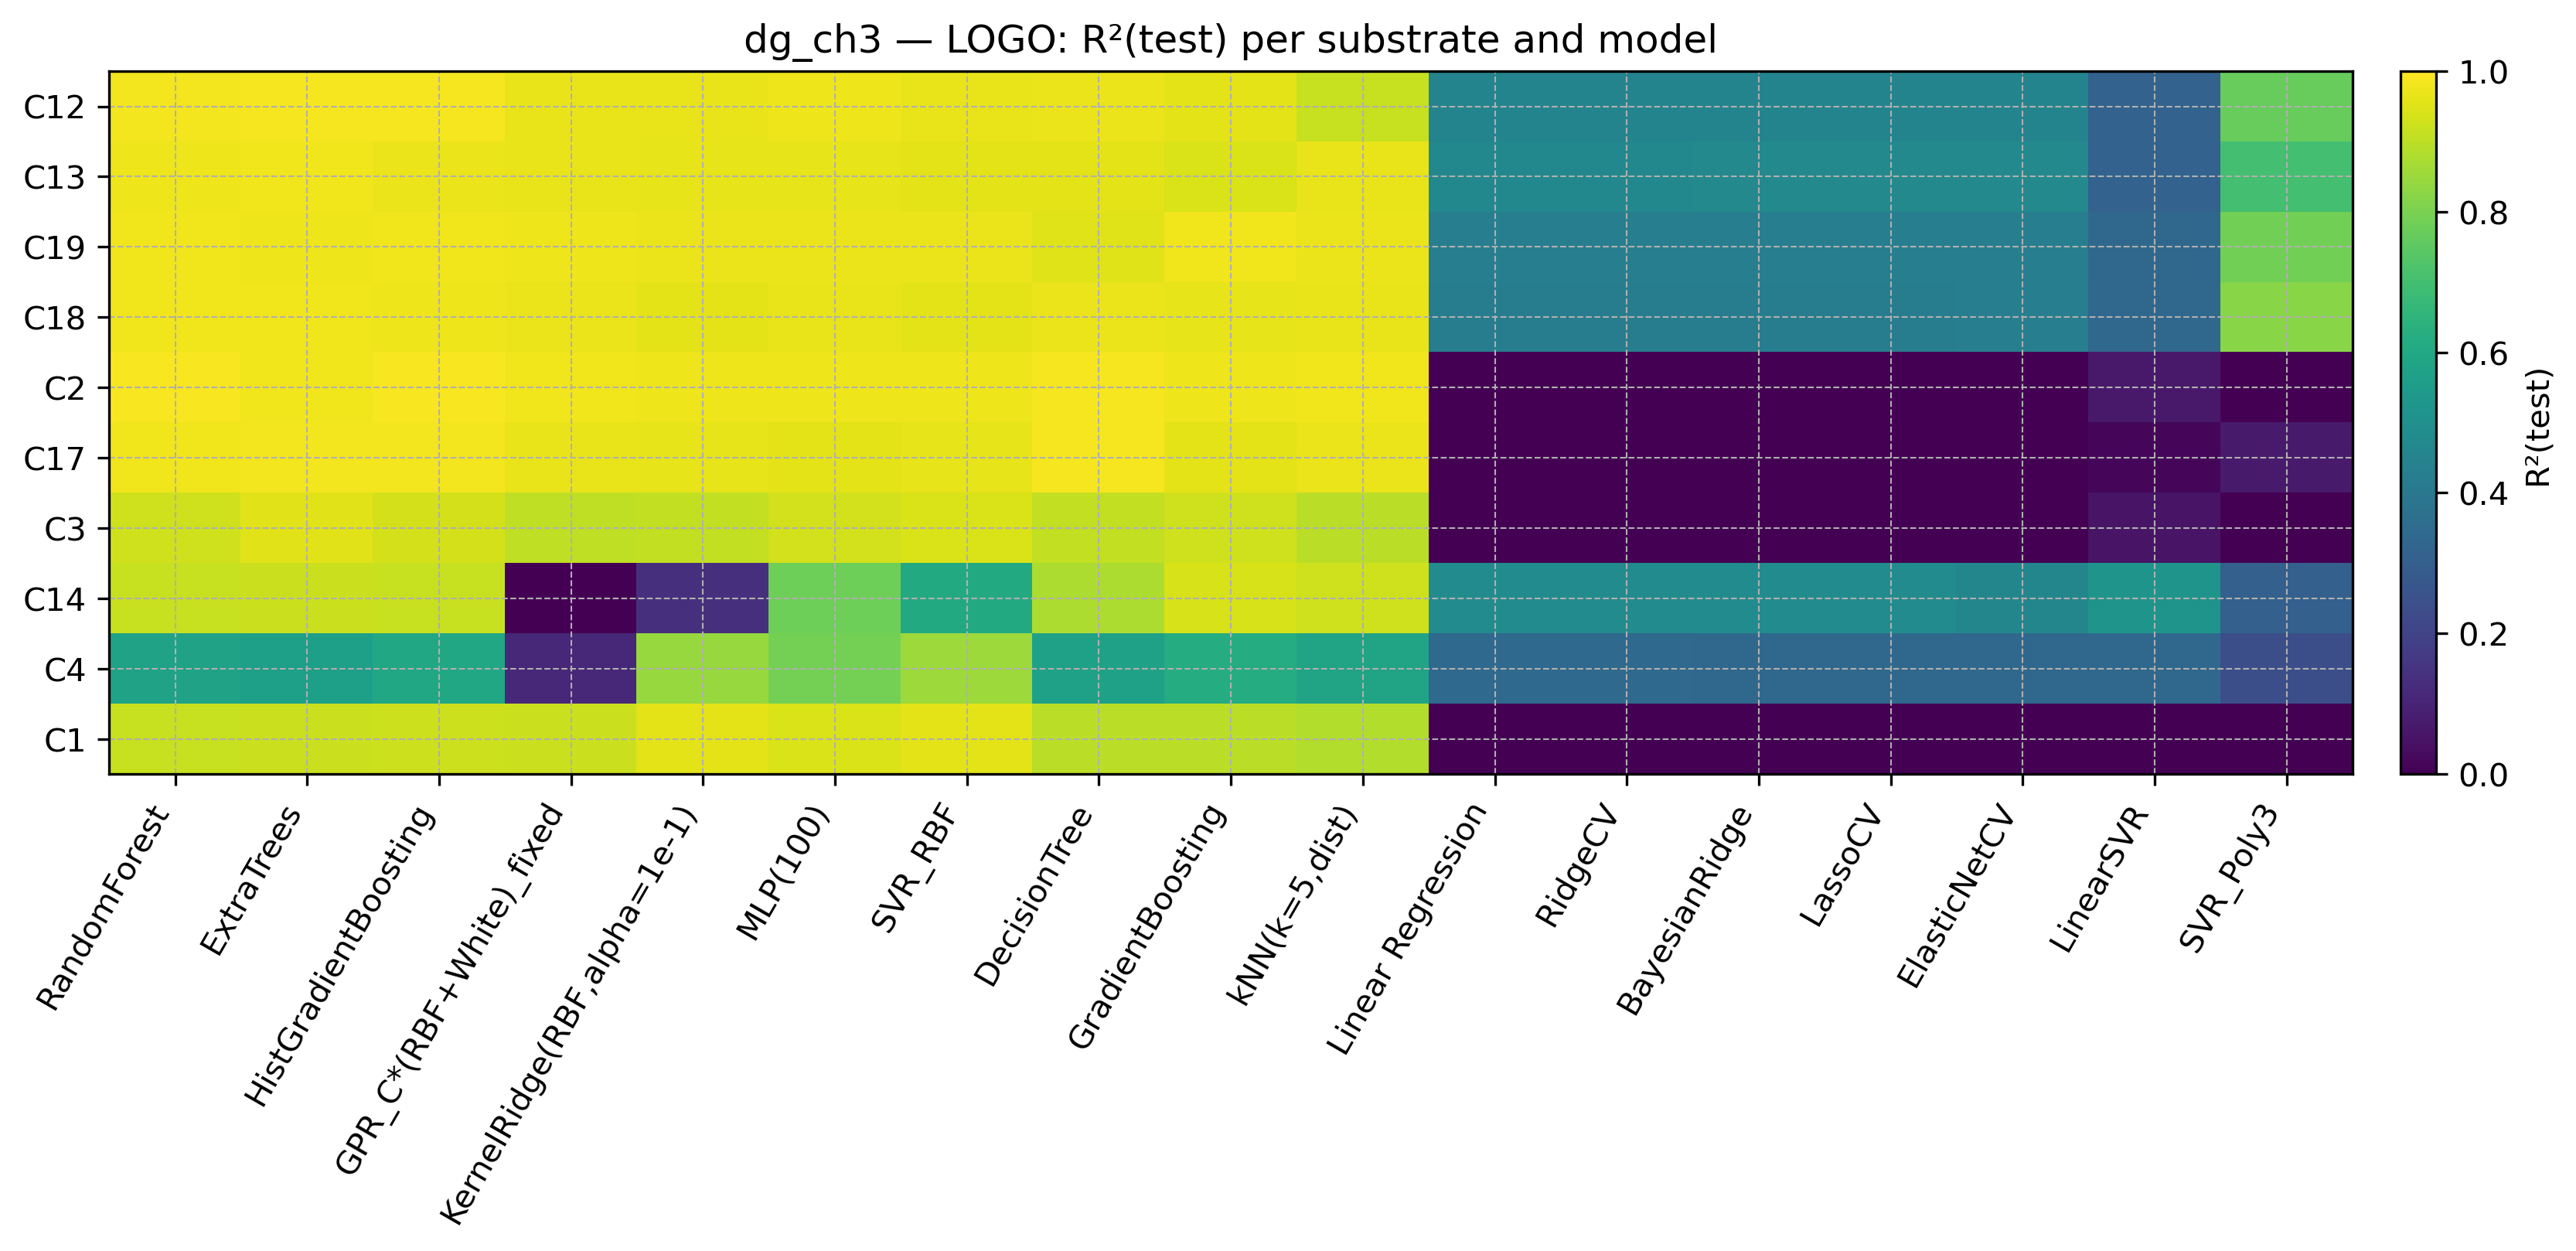


Descriptor: nbo_boltz


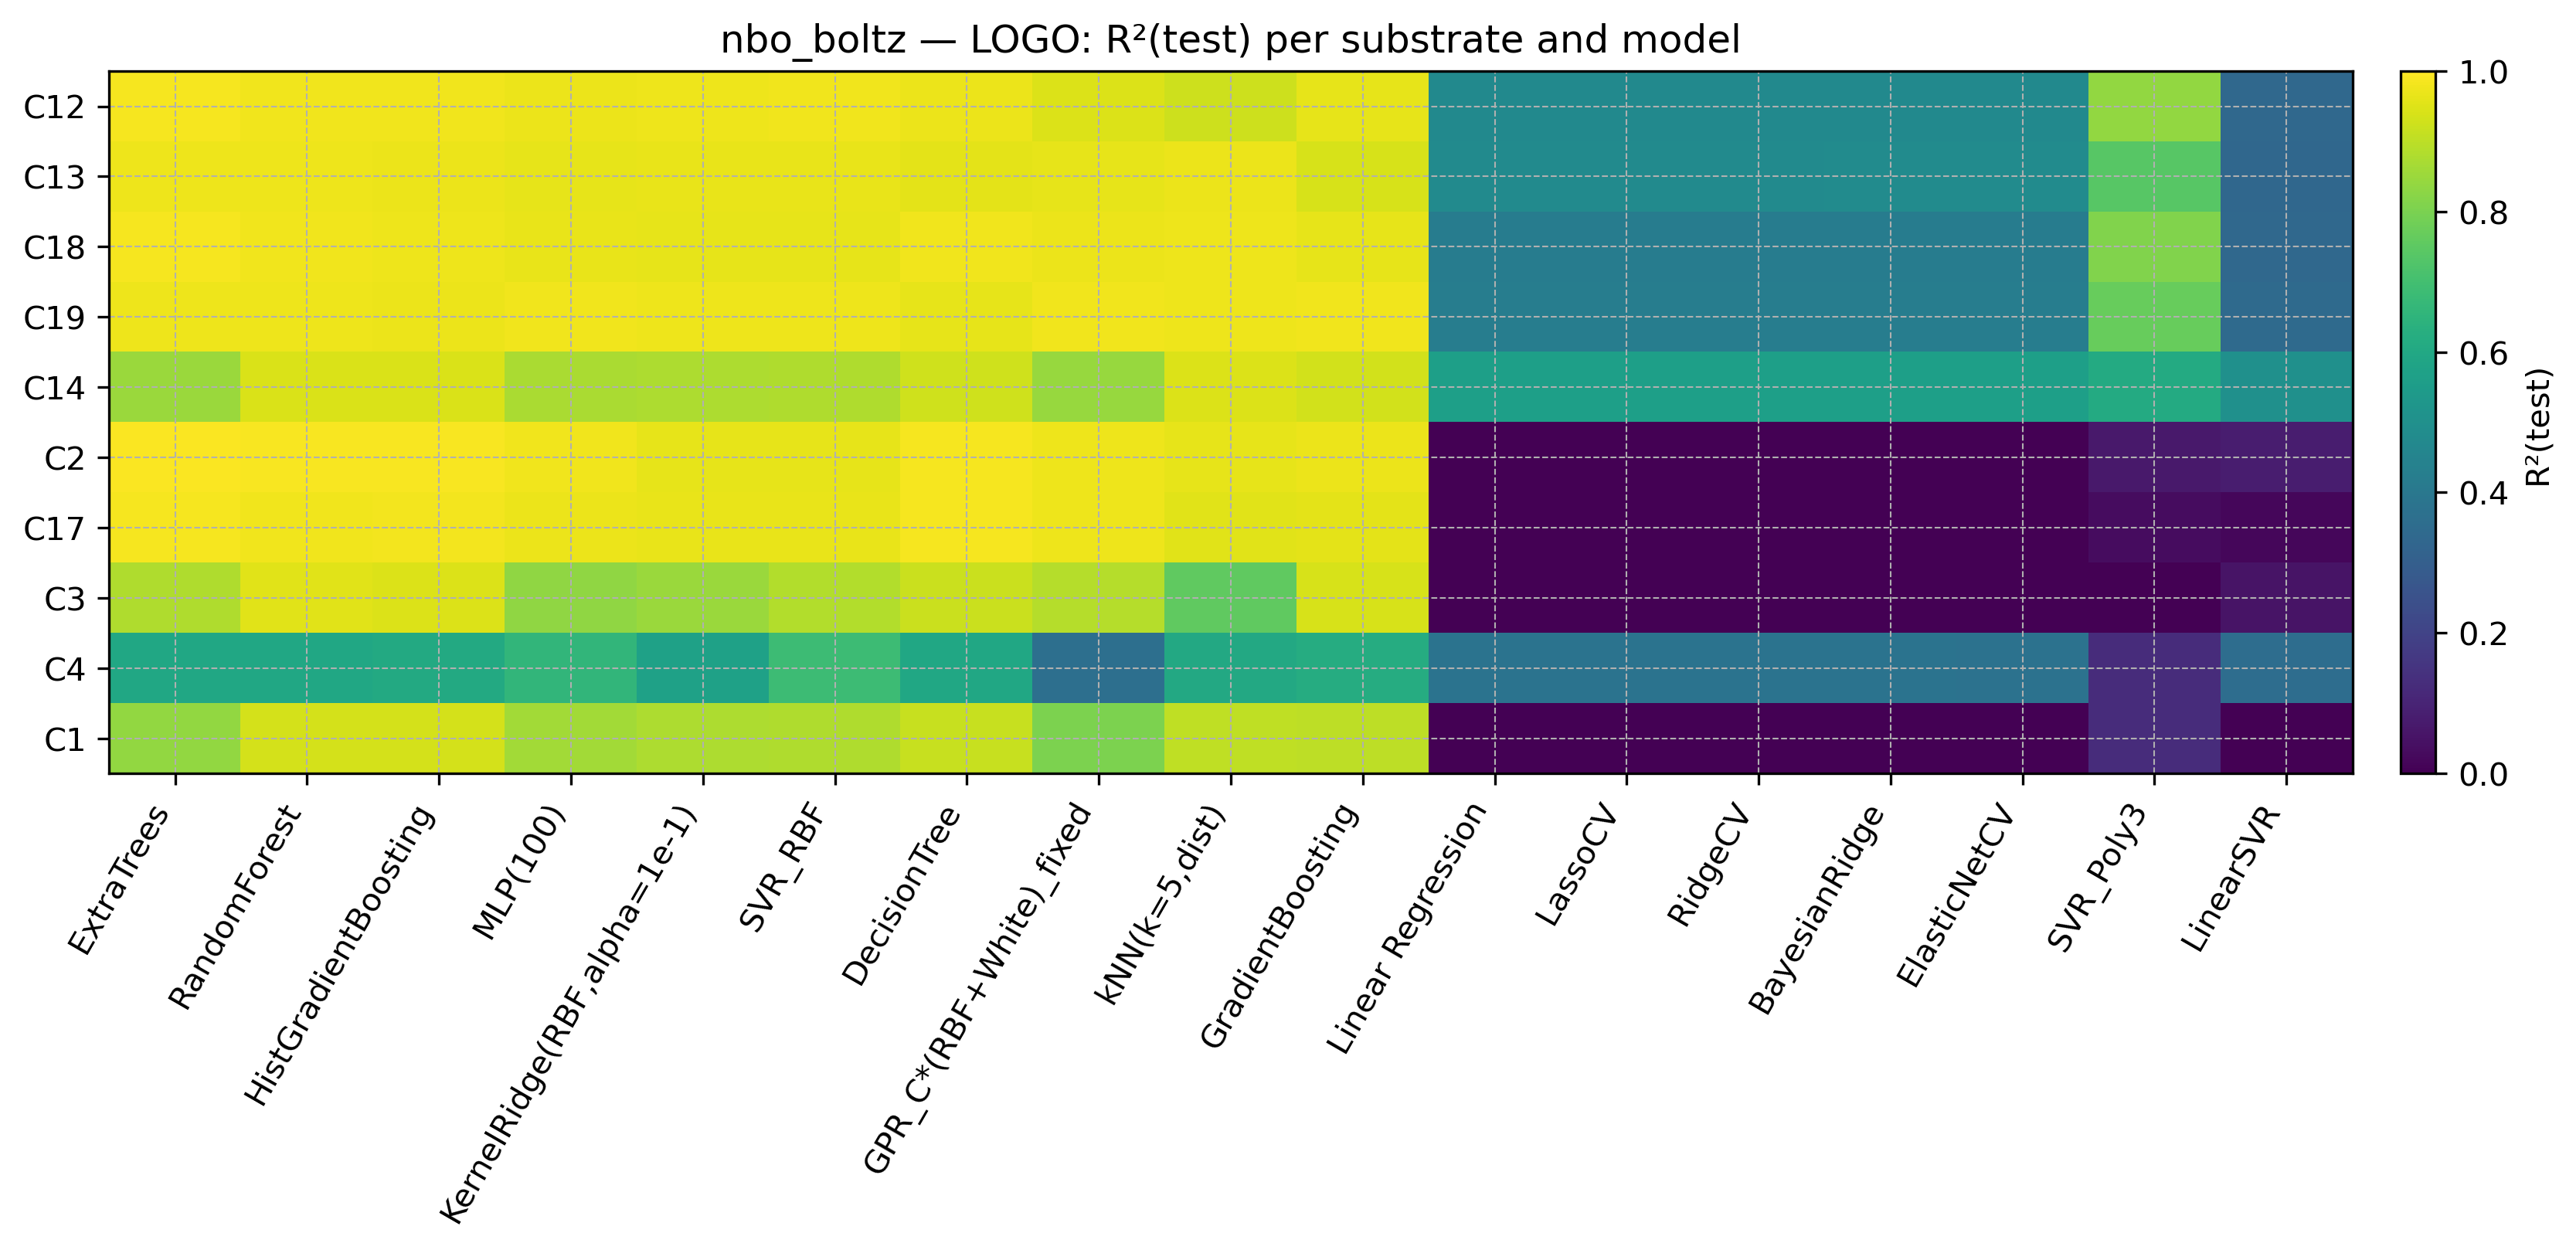


Descriptor: nbo_min


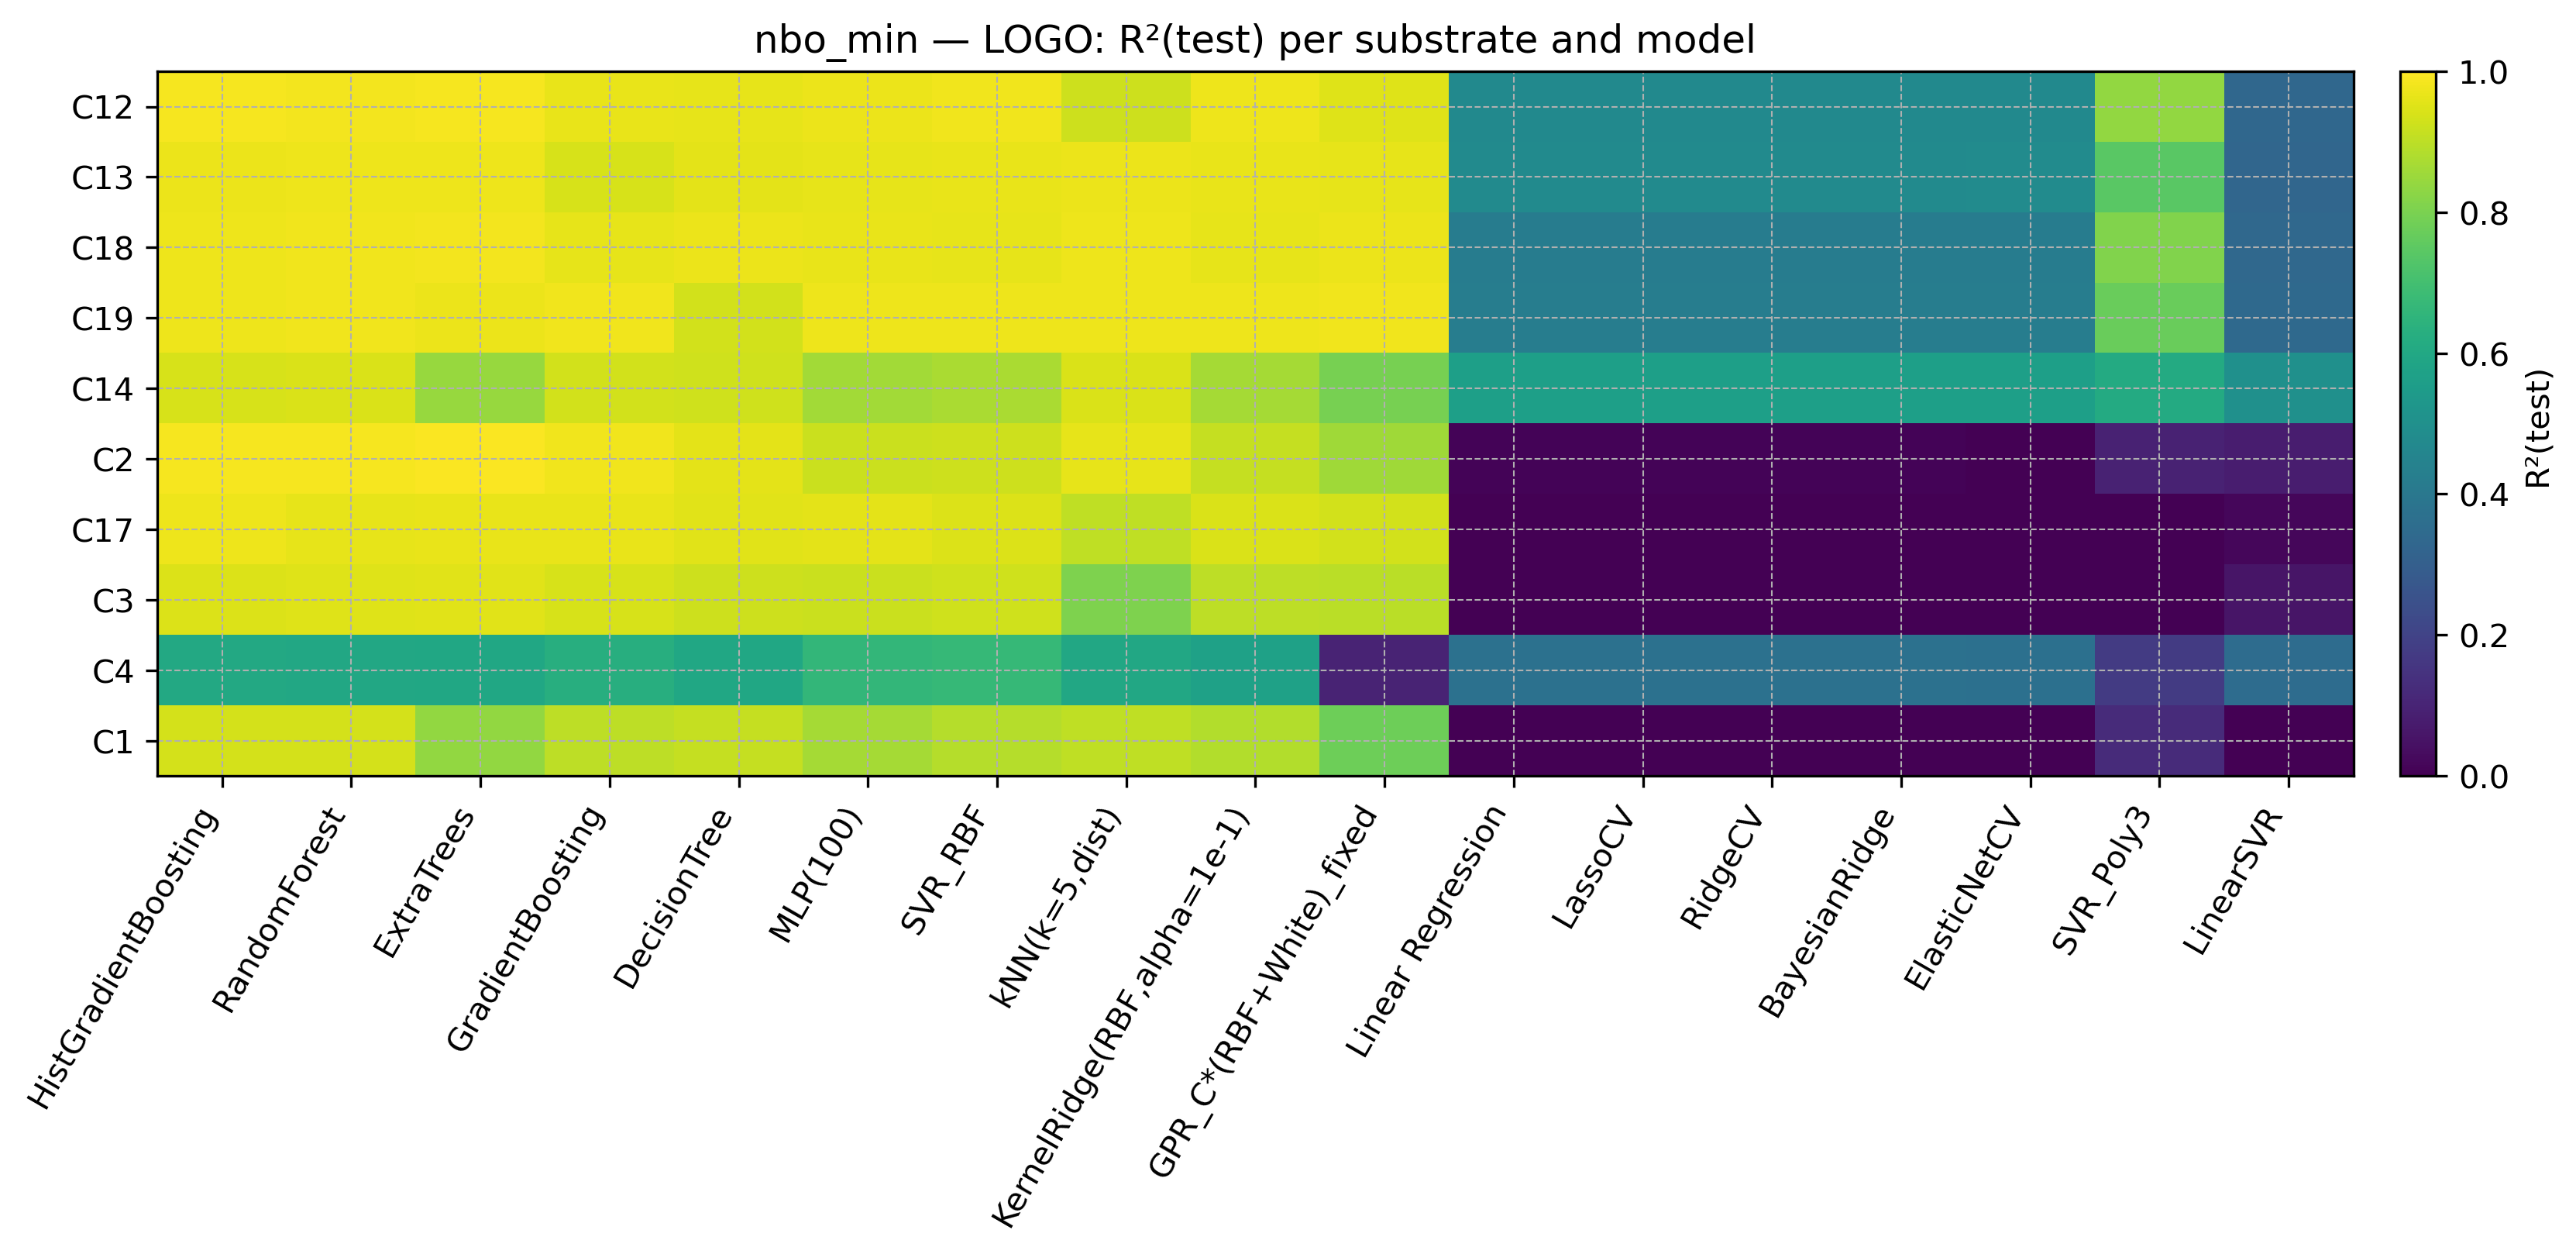


Finished generating descriptor heatmaps (saved in analysis_logo/).


In [18]:
import seaborn as sns
from IPython.display import display, Image

descriptor_list = sorted(df_q2["Descriptor"].unique())
print(f"Generating per-descriptor heatmaps for {len(descriptor_list)} descriptors...")

# Display only the top-k descriptors inline (based on global Q² leaderboard)
top_k_display = 3
top_descriptors = (
    desc_strength_all["Descriptor"].head(top_k_display).tolist()
    if top_k_display is not None
    else []
)

for desc in descriptor_list:
    desc_sanitized = sanitize(desc)
    folds_file = f"results_logo_each_combined_{desc_sanitized}.csv"

    if not os.path.exists(folds_file):
        print(f"Warning: per-fold file not found for descriptor '{desc}' -> {folds_file}")
        continue

    df_folds = pd.read_csv(folds_file)

    # ------------------------------------------------------------
    # Build substrate × model heatmap of R²(test)
    # ------------------------------------------------------------
    pivot_r2 = df_folds.pivot(
        index="Heldout_Substrate",
        columns="Model",
        values="R2(test)"
    )

    # Order substrates by mean R², models by median R²
    sub_order = pivot_r2.mean(axis=1).sort_values(ascending=False).index.tolist()
    model_order_desc = (
        df_folds.groupby("Model")["R2(test)"]
                .median()
                .sort_values(ascending=False)
                .index.tolist()
    )

    pivot_r2 = pivot_r2.loc[sub_order, model_order_desc]

    # ------------------------------------------------------------
    # Heatmap (scaled 0 → 1)
    # ------------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(0.55 * len(model_order_desc) + 2,
                 0.35 * len(sub_order) + 2)
    )
    
    im = ax.imshow(
        pivot_r2.values,
        aspect="auto",
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0,
        cmap="viridis"
    )

    ax.set_xticks(range(len(model_order_desc)))
    ax.set_xticklabels(model_order_desc, rotation=60, ha="right")
    ax.set_yticks(range(len(sub_order)))
    ax.set_yticklabels(sub_order)

    ax.set_title(f"{desc} — LOGO: R²(test) per substrate and model")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label("R²(test)")

    plt.tight_layout()

    # Save directly in analysis_logo/
    heat_file = ANALYSIS_LOGO_DIR / f"heatmap_R2_{desc_sanitized}.png"
    fig.savefig(heat_file, dpi=300, bbox_inches="tight", transparent=True)
    plt.close(fig)

    # Display only for top-k descriptors
    if desc in top_descriptors:
        print(f"\nDescriptor: {desc}")
        display(Image(filename=str(heat_file)))

print("\nFinished generating descriptor heatmaps (saved in analysis_logo/).")

### Step 5: Nested LOGO hyperparameter optimization for selected models and descriptors

In this step we perform **nested leave-one-group-out (LOGO) hyperparameter optimization**
for a subset of promising model/descriptor combinations.

- We restrict attention to a selection of the best-performing descriptors for **CX**. 
- For each descriptor, we build features from the four reaction parameters plus that descriptor.
- For each of the following models, we tune hyperparameters by **nested grouped CV** for the best-performing ML-regression models.
  - RandomForestRegressor  
  - ExtraTreesRegressor  
  - HistGradientBoostingRegressor (if available)  
  - GradientBoostingRegressor  
  - DecisionTreeRegressor  
  - kNN(k=5, distance-weighted)  
  - SVR with RBF kernel  
  - Kernel Ridge Regression (RBF kernel)  
  - MLPRegressor (one hidden layer, 100 units)

For each (descriptor, model) pair:

1. The **outer loop** is LOGO over `carbonyl_nr`, holding out one carbonyl at a time.
2. Within each outer training set, we run **inner GroupKFold CV** (grouped by substrate)
   combined with a `GridSearchCV` over a small, physically motivated hyperparameter grid,
   using R² as the scoring metric.
3. We record:
   - per-fold outer metrics (R², MAE, RMSE and inner-CV best score/params),
   - pooled LOGO performance (R², MAE, RMSE) per (descriptor, model),
   - per-sample out-of-fold predictions.

Results are written to `logo_hpo_outputs/`:
- `results_logo_hpo_summary.csv` — pooled LOGO metrics and consensus hyperparameters per (descriptor, model)  
- `results_logo_hpo_predictions.csv` — out-of-fold predictions per sample  
- `per_fold_metrics.csv` — long-format metrics for each outer LOGO fold  
- `best_descriptor_per_model.csv` — best descriptor for each model by LOGO R²

In [21]:
from pathlib import Path
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV

# --------------------------------------------------------------------
# Configuration for HPO
# --------------------------------------------------------------------
HPO_OUTDIR = Path("logo_hpo_outputs")
HPO_OUTDIR.mkdir(exist_ok=True, parents=True)

# Restrict to selected descriptors (if present in the parameter table)
HPO_DESCRIPTORS = [d for d in ["nbo_boltz", "dg_ch3"] if d in param_cols]
if not HPO_DESCRIPTORS:
    raise ValueError(
        "None of the descriptors are present in the parameter table."
    )

print("Running nested LOGO HPO for descriptors:", HPO_DESCRIPTORS)


# --------------------------------------------------------------------
# HPO model definitions and grids
# --------------------------------------------------------------------
def build_hpo_models_and_grids(random_state=RANDOM_STATE):
    """
    Models and hyperparameter grids used for nested LOGO HPO.
    All models are regression estimators matching the main ML sweep.
    """
    grids = []

    # Trees / Ensembles (no scaling)
    grids.append((
        "RandomForest",
        RandomForestRegressor(random_state=random_state, n_jobs=-1),
        {
            "model__n_estimators": [200, 500],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 2, 5],
        },
    ))

    grids.append((
        "ExtraTrees",
        ExtraTreesRegressor(random_state=random_state, n_jobs=-1),
        {
            "model__n_estimators": [300, 600],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_leaf": [1, 2, 5],
        },
    ))

    grids.append((
        "HistGradientBoosting",
        HistGradientBoostingRegressor(random_state=random_state),
        {
            "model__learning_rate": [0.05, 0.1, 0.2],
            "model__max_depth": [None, 6, 12],
            "model__max_leaf_nodes": [31, 63],
        },
    ))

    grids.append((
        "GradientBoosting",
        GradientBoostingRegressor(random_state=random_state),
        {
            "model__n_estimators": [200, 500],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3],
        },
    ))

    grids.append((
        "DecisionTree",
        DecisionTreeRegressor(random_state=random_state),
        {
            "model__max_depth": [None, 5, 10, 20],
            "model__min_samples_leaf": [1, 2, 5],
        },
    ))

    # Distance/kernel/NN models (need scaling)
    grids.append((
        "kNN(k=5,dist)",
        KNeighborsRegressor(n_neighbors=5, weights="distance"),
        {
            "model__p": [1, 2],
        },
    ))

    grids.append((
        "SVR_RBF",
        SVR(kernel="rbf"),
        {
            "model__C": [1, 10, 100],
            "model__gamma": ["scale", 0.1, 0.01],
        },
    ))

    grids.append((
        "KernelRidge_RBF",
        KernelRidge(kernel="rbf"),
        {
            "model__alpha": [1e-1],  # kept fixed as in cluster script
            "model__gamma": [0.001, 0.01, 0.1, 1.0],
        },
    ))

    grids.append((
        "MLP(100)",
        MLPRegressor(hidden_layer_sizes=(100,), max_iter=2000, random_state=random_state),
        {
            "model__activation": ["relu", "tanh"],
            "model__alpha": [1e-4, 1e-3],
            "model__learning_rate_init": [1e-3, 1e-2],
        },
    ))

    return grids


def needs_scaler_hpo(model_name: str) -> bool:
    """Which models require feature scaling in the HPO pipelines."""
    return model_name in {"kNN(k=5,dist)", "SVR_RBF", "KernelRidge_RBF", "MLP(100)"}


def make_hpo_pipeline(model_name: str, estimator):
    """Attach a StandardScaler where appropriate."""
    if needs_scaler_hpo(model_name):
        return Pipeline([("scaler", StandardScaler()), ("model", estimator)])
    return Pipeline([("model", estimator)])


# --------------------------------------------------------------------
# Nested LOGO HPO
# --------------------------------------------------------------------
models_and_grids = build_hpo_models_and_grids(RANDOM_STATE)
outer_logo = LeaveOneGroupOut()

summary_rows = []
pred_rows = []
per_fold_rows = []

for descriptor in HPO_DESCRIPTORS:
    print("\n" + "#" * 72)
    print(f"Descriptor: {descriptor}")
    print("#" * 72)

    # Build dataset: reaction parameters + this descriptor
    sub_params = df_params[[join_key, descriptor]].copy()
    merged = df_ds.merge(sub_params, on=join_key, how="inner")

    feature_cols = [c for c in reaction_cols if c in merged.columns] + [descriptor]
    mask_cols = feature_cols + ["lg_k_obs", join_key]
    merged = merged.dropna(subset=mask_cols).copy()

    if merged.shape[0] < 25:
        print(f"Skipping descriptor '{descriptor}' (only {merged.shape[0]} usable rows)")
        continue

    X_all = merged[feature_cols].astype(float).values
    y = merged["lg_k_obs"].astype(float).values
    groups = merged[join_key].astype(str).values

    print(
        f"LOGO outer CV: n_samples={len(y)}, "
        f"n_groups={np.unique(groups).size}, "
        f"n_features={len(feature_cols)}"
    )

    for model_name, estimator, grid in models_and_grids:
        print(f"\nModel: {model_name}")
        pipe = make_hpo_pipeline(model_name, estimator)

        y_true_all, y_pred_all, group_ids_all = [], [], []
        best_params_list = []

        # Outer LOGO loop
        for fold_idx, (tr_idx, te_idx) in enumerate(outer_logo.split(X_all, y, groups), start=1):
            X_tr, X_te = X_all[tr_idx], X_all[te_idx]
            y_tr, y_te = y[tr_idx], y[te_idx]
            groups_tr = groups[tr_idx]
            heldout_group = np.unique(groups[te_idx])
            heldout_group = str(heldout_group[0]) if heldout_group.size > 0 else "UNKNOWN"

            # Inner grouped CV for hyperparameters
            n_groups_tr = len(np.unique(groups_tr))
            n_splits = min(5, max(2, n_groups_tr))
            inner_cv = GroupKFold(n_splits=n_splits)

            gs = GridSearchCV(
                estimator=pipe,
                param_grid=grid,
                scoring="r2",
                cv=inner_cv.split(X_tr, y_tr, groups_tr),
                n_jobs=-1,
                refit=True,
                verbose=0,
            )
            gs.fit(X_tr, y_tr)
            best_params_list.append(gs.best_params_)

            # Outer-fold predictions
            y_hat = gs.predict(X_te)
            y_true_all.extend(y_te.tolist())
            y_pred_all.extend(y_hat.tolist())
            group_ids_all.extend(groups[te_idx].tolist())

            r2_fold = r2_score(y_te, y_hat)
            mae_fold = mean_absolute_error(y_te, y_hat)
            rmse_fold = rmse(y_te, y_hat)

            print(
                f"  Fold {fold_idx:02d} | held-out={heldout_group} | "
                f"R²={r2_fold:.3f}, MAE={mae_fold:.3f}, RMSE={rmse_fold:.3f}"
            )

            per_fold_rows.append({
                "descriptor": descriptor,
                "model": model_name,
                "group": heldout_group,
                "fold_idx": fold_idx,
                "n_train": int(len(y_tr)),
                "n_test": int(len(y_te)),
                "r2_fold": float(r2_fold),
                "mae_fold": float(mae_fold),
                "rmse_fold": float(rmse_fold),
                "best_score_inner": float(gs.best_score_),
                "best_params_inner": json.dumps(gs.best_params_),
            })

        # Pooled LOGO metrics for this (descriptor, model)
        y_true_all = np.asarray(y_true_all)
        y_pred_all = np.asarray(y_pred_all)
        R2_logo = r2_score(y_true_all, y_pred_all)
        MAE_logo = mean_absolute_error(y_true_all, y_pred_all)
        RMSE_logo = rmse(y_true_all, y_pred_all)

        # Store per-sample predictions
        for yt, yp, g in zip(y_true_all, y_pred_all, group_ids_all):
            pred_rows.append({
                "descriptor": descriptor,
                "model": model_name,
                "group": g,
                "y_true": float(yt),
                "y_pred": float(yp),
            })

        # Consensus (mode) of best hyperparameters across outer folds
        if best_params_list:
            serial = [tuple(sorted(d.items())) for d in best_params_list]
            most_common = Counter(serial).most_common(1)[0][0]
            best_params_mode = dict(most_common)
        else:
            best_params_mode = {}

        summary_rows.append({
            "descriptor": descriptor,
            "model": model_name,
            "r2_logo": float(R2_logo),
            "mae_logo": float(MAE_logo),
            "rmse_logo": float(RMSE_logo),
            "best_params_mode": json.dumps(best_params_mode),
        })

# --------------------------------------------------------------------
# Save HPO outputs
# --------------------------------------------------------------------
summary_df = pd.DataFrame(summary_rows).sort_values(
    ["model", "r2_logo"], ascending=[True, False]
)
preds_df = pd.DataFrame(pred_rows)
per_fold_df = pd.DataFrame(per_fold_rows).sort_values(
    ["model", "descriptor", "group", "fold_idx"]
)

out_summary = HPO_OUTDIR / "results_logo_hpo_summary.csv"
out_preds = HPO_OUTDIR / "results_logo_hpo_predictions.csv"
out_perfold = HPO_OUTDIR / "per_fold_metrics.csv"
out_bestdesc = HPO_OUTDIR / "best_descriptor_per_model.csv"

summary_df.to_csv(out_summary, index=False)
preds_df.to_csv(out_preds, index=False)
per_fold_df.to_csv(out_perfold, index=False)

# Best descriptor per model by LOGO R²
best_rows = []
for model_name, gdf in summary_df.groupby("model", sort=False):
    best_rows.append(
        gdf.sort_values("r2_logo", ascending=False).iloc[0].to_dict()
    )
best_df = pd.DataFrame(best_rows).sort_values("r2_logo", ascending=False)
best_df.to_csv(out_bestdesc, index=False)

print("\nWrote HPO outputs to:")
for fp in [out_summary, out_preds, out_perfold, out_bestdesc]:
    print(f"  - {fp.resolve()}")

print("\nBest descriptor per model (nested LOGO HPO):")
display(best_df)

Running nested LOGO HPO for descriptors: ['nbo_boltz', 'dg_ch3']

########################################################################
Descriptor: nbo_boltz
########################################################################
LOGO outer CV: n_samples=6889, n_groups=10, n_features=5

Model: RandomForest
  Fold 01 | held-out=C1 | R²=0.921, MAE=0.238, RMSE=0.294
  Fold 02 | held-out=C12 | R²=0.979, MAE=0.160, RMSE=0.212
  Fold 03 | held-out=C13 | R²=0.974, MAE=0.159, RMSE=0.224
  Fold 04 | held-out=C14 | R²=0.946, MAE=0.203, RMSE=0.253
  Fold 05 | held-out=C17 | R²=0.984, MAE=0.096, RMSE=0.130
  Fold 06 | held-out=C18 | R²=0.981, MAE=0.164, RMSE=0.213
  Fold 07 | held-out=C19 | R²=0.972, MAE=0.154, RMSE=0.222
  Fold 08 | held-out=C2 | R²=0.989, MAE=0.083, RMSE=0.107
  Fold 09 | held-out=C3 | R²=0.935, MAE=0.173, RMSE=0.229
  Fold 10 | held-out=C4 | R²=0.609, MAE=0.555, RMSE=0.632

Model: ExtraTrees


/Users/robertmayer/miniconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Fold 01 | held-out=C1 | R²=0.845, MAE=0.367, RMSE=0.412


/Users/robertmayer/miniconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  Fold 02 | held-out=C12 | R²=0.990, MAE=0.110, RMSE=0.144


...

/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extma

  Fold 09 | held-out=C3 | R²=0.935, MAE=0.164, RMSE=0.228


/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/robertmayer/miniconda3/lib/python3.12/site-packages/sklearn/utils/extma

  Fold 10 | held-out=C4 | R²=0.781, MAE=0.400, RMSE=0.473

Wrote HPO outputs to:
  - /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_screen_v3/logo_hpo_outputs/results_logo_hpo_summary.csv
  - /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_screen_v3/logo_hpo_outputs/results_logo_hpo_predictions.csv
  - /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_screen_v3/logo_hpo_outputs/per_fold_metrics.csv
  - /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_screen_v3/logo_hpo_outputs/best_descriptor_per_model.csv

Best descriptor per model (nested LOGO HPO):


,descriptor,model,r2_logo,mae_logo,rmse_logo,best_params_mode
3,nbo_boltz,HistGradientBoosting,0.949194,0.192101,0.268500,"{""model__learning_rate"": 0.1, ""model__max_dept..."
6,nbo_boltz,RandomForest,0.947473,0.189646,0.273010,"{""model__max_depth"": null, ""model__min_samples..."
1,dg_ch3,ExtraTrees,0.946801,0.188783,0.274752,"{""model__max_depth"": null, ""model__min_samples..."
5,dg_ch3,MLP(100),0.946351,0.208102,0.275911,"{""model__activation"": ""tanh"", ""model__alpha"": ..."
2,nbo_boltz,GradientBoosting,0.945900,0.202522,0.277069,"{""model__learning_rate"": 0.1, ""model__max_dept..."
0,nbo_boltz,DecisionTree,0.940540,0.203694,0.290471,"{""model__max_depth"": 20, ""model__min_samples_l..."
4,nbo_boltz,KernelRidge_RBF,0.935421,0.232774,0.302715,"{""model__alpha"": 0.1, ""model__gamma"": 0.1}"
7,nbo_boltz,SVR_RBF,0.931580,0.238916,0.311589,"{""model__C"": 1, ""model__gamma"": 0.1}"
8,dg_ch3,"kNN(k=5,dist)",0.928519,0.222771,0.318482,"{""model__p"": 1}"


### Step 5: Hyperopt-based final tuning for RandomForest and HistGradientBoosting (nbo_boltz)

In the final step, we perform an extensive hyperparameter optimization for the two
best-performing ensemble models — Random Forest Regressor and HistGradientBoosting
Regressor — using **nbo_boltz** as the single descriptor for the carbonyl CX
(together with the four reaction parameters).

For each model we:

1. Construct the dataset \[pH, pKₐ(HA), \[HA\], \[Nu\], nbo_boltz\] → lg k_obs
   and use `carbonyl_nr` as the LOGO grouping variable.
2. Use **hyperopt** (TPE algorithm) to search the hyperparameter space, where the
   objective is **1 − Q²(LOGO)**, with Q² computed as the pooled R² across all
   leave-one-carbonyl-out folds.
3. Re-run LOGO with the best hyperparameters to obtain final cross-validated
   predictions and metrics (Q², MAE, RMSE).
4. Generate diagnostic plots:
   - global LOGO parity plot (observed vs. predicted lg k_obs),
   - per-carbonyl MAE and R² bar plots.

All outputs are written to `final_hyperopt_nbo_boltz/`, including:
best hyperparameters, LOGO predictions, summary metrics, and diagnostic figures
for both tuned models.

In [25]:
from pathlib import Path
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval

# --------------------------------------------------------------------
# Dataset for nbo_boltz
# --------------------------------------------------------------------
FINAL_DIR = Path("final_hyperopt_nbo_boltz")
FINAL_PLOTS_DIR = FINAL_DIR / "plots"
FINAL_DIR.mkdir(parents=True, exist_ok=True)
FINAL_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

descriptor = "nbo_boltz"
if descriptor not in df_params.columns:
    raise ValueError(f"Descriptor '{descriptor}' not found in carbonyl_parameters.xlsx")

sub_params = df_params[[join_key, descriptor]].copy()
merged = df_ds.merge(sub_params, on=join_key, how="inner")

feature_cols = [c for c in reaction_cols if c in merged.columns] + [descriptor]
merged = merged.dropna(subset=feature_cols + ["lg_k_obs", join_key]).copy()

X_nbo = merged[feature_cols].astype(float).values
y_nbo = merged["lg_k_obs"].astype(float).values
groups_nbo = merged[join_key].astype(str).values
target_name = "lg_k_obs"

print(
    f"Final HPO dataset (nbo_boltz): "
    f"n_samples={len(y_nbo)}, n_features={len(feature_cols)}, "
    f"n_groups={len(np.unique(groups_nbo))}"
)

logo = LeaveOneGroupOut()

# --------------------------------------------------------------------
# Helper: Q²(LOGO) for a given estimator
# --------------------------------------------------------------------
def logo_q2_for_estimator(estimator, X, y, groups):
    y_true_all, y_pred_all = [], []
    for tr_idx, te_idx in logo.split(X, y, groups):
        est = clone(estimator)
        est.fit(X[tr_idx], y[tr_idx])
        y_hat = est.predict(X[te_idx])
        y_true_all.extend(y[te_idx].tolist())
        y_pred_all.extend(y_hat.tolist())
    y_true_all = np.asarray(y_true_all)
    y_pred_all = np.asarray(y_pred_all)
    q2 = r2_score(y_true_all, y_pred_all)
    return q2


# --------------------------------------------------------------------
# Hyperopt search spaces
# --------------------------------------------------------------------
rf_space = {
    "n_estimators": hp.quniform("rf_n_estimators", 200, 1200, 1),
    "max_depth": hp.choice("rf_max_depth", [None, 10, 20, 40]),
    "min_samples_leaf": hp.quniform("rf_min_samples_leaf", 1, 8, 1),
    "max_features": hp.choice("rf_max_features", ["sqrt", "log2", None]),
    "bootstrap": hp.choice("rf_bootstrap", [True, False]),
}

hgb_space = {
    "learning_rate": hp.loguniform("hgb_lr", np.log(0.02), np.log(0.3)),
    "max_depth": hp.choice("hgb_max_depth", [None, 6, 10, 14]),
    "max_leaf_nodes": hp.quniform("hgb_max_leaf_nodes", 31, 255, 1),
    "min_samples_leaf": hp.quniform("hgb_min_samples_leaf", 10, 80, 1),
    "l2_regularization": hp.loguniform("hgb_l2", np.log(1e-4), np.log(1.0)),
}


# --------------------------------------------------------------------
# Objective wrappers for hyperopt
# --------------------------------------------------------------------
def rf_from_params(params):
    return RandomForestRegressor(
        n_estimators=int(params["n_estimators"]),
        max_depth=params["max_depth"],
        min_samples_leaf=int(params["min_samples_leaf"]),
        max_features=params["max_features"],
        bootstrap=bool(params["bootstrap"]),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def hgb_from_params(params):
    return HistGradientBoostingRegressor(
        learning_rate=float(params["learning_rate"]),
        max_depth=params["max_depth"],
        max_leaf_nodes=int(params["max_leaf_nodes"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        l2_regularization=float(params["l2_regularization"]),
        random_state=RANDOM_STATE,
    )


def make_objective(build_model_fn, model_label):
    def objective(params):
        model = build_model_fn(params)
        q2 = logo_q2_for_estimator(model, X_nbo, y_nbo, groups_nbo)
        loss = 1.0 - q2  # minimize 1 − Q²
        return {"loss": loss, "status": STATUS_OK, "q2": q2}
    return objective


# --------------------------------------------------------------------
# Hyperopt runs
# --------------------------------------------------------------------
max_evals = 300 

# RandomForest
rf_trials = Trials()
rf_obj = make_objective(rf_from_params, "RandomForest")

best_rf = fmin(
    rf_obj,
    space=rf_space,
    algo=tpe.suggest,
    max_evals=max_evals,
    trials=rf_trials,
    rstate=np.random.default_rng(RANDOM_STATE),
)
best_rf_params = space_eval(rf_space, best_rf)
rf_best_model = rf_from_params(best_rf_params)

print("\nRandomForest — best hyperparameters (hyperopt):")
for k, v in best_rf_params.items():
    print(f"  {k}: {v}")

# HistGradientBoosting
hgb_trials = Trials()
hgb_obj = make_objective(hgb_from_params, "HistGradientBoosting")

best_hgb = fmin(
    hgb_obj,
    space=hgb_space,
    algo=tpe.suggest,
    max_evals=max_evals,
    trials=hgb_trials,
    rstate=np.random.default_rng(RANDOM_STATE + 1),
)
best_hgb_params = space_eval(hgb_space, best_hgb)
hgb_best_model = hgb_from_params(best_hgb_params)

print("\nHistGradientBoosting — best hyperparameters (hyperopt):")
for k, v in best_hgb_params.items():
    print(f"  {k}: {v}")

# --------------------------------------------------------------------
# Final LOGO predictions with best hyperparameters
# --------------------------------------------------------------------
def logo_predictions(estimator, X, y, groups):
    y_true_all, y_pred_all, group_all = [], [], []
    for tr_idx, te_idx in logo.split(X, y, groups):
        est = clone(estimator)
        est.fit(X[tr_idx], y[tr_idx])
        y_hat = est.predict(X[te_idx])
        y_true_all.extend(y[te_idx].tolist())
        y_pred_all.extend(y_hat.tolist())
        group_all.extend(groups[te_idx].tolist())
    y_true_all = np.asarray(y_true_all)
    y_pred_all = np.asarray(y_pred_all)
    group_all = np.asarray(group_all)
    q2 = r2_score(y_true_all, y_pred_all)
    mae_cv = mean_absolute_error(y_true_all, y_pred_all)
    rmse_cv = rmse(y_true_all, y_pred_all)
    return y_true_all, y_pred_all, group_all, q2, mae_cv, rmse_cv


(y_rf_true, y_rf_pred, g_rf, q2_rf, mae_rf, rmse_rf) = logo_predictions(
    rf_best_model, X_nbo, y_nbo, groups_nbo
)
(y_hgb_true, y_hgb_pred, g_hgb, q2_hgb, mae_hgb, rmse_hgb) = logo_predictions(
    hgb_best_model, X_nbo, y_nbo, groups_nbo
)

print(
    f"\nRandomForest (nbo_boltz) — LOGO: Q²={q2_rf:.3f}, "
    f"MAE={mae_rf:.3f}, RMSE={rmse_rf:.3f}"
)
print(
    f"HistGradientBoosting (nbo_boltz) — LOGO: Q²={q2_hgb:.3f}, "
    f"MAE={mae_hgb:.3f}, RMSE={rmse_hgb:.3f}"
)

# --------------------------------------------------------------------
# Save numeric results
# --------------------------------------------------------------------
pd.DataFrame(rf_trials.results).to_csv(
    FINAL_DIR / "rf_hyperopt_trials.csv", index=False
)
pd.DataFrame(hgb_trials.results).to_csv(
    FINAL_DIR / "hgb_hyperopt_trials.csv", index=False
)

pd.DataFrame(
    {
        "Observed": y_rf_true,
        "Predicted": y_rf_pred,
        "Group": g_rf,
    }
).to_csv(FINAL_DIR / "rf_logo_predictions.csv", index=False)

pd.DataFrame(
    {
        "Observed": y_hgb_true,
        "Predicted": y_hgb_pred,
        "Group": g_hgb,
    }
).to_csv(FINAL_DIR / "hgb_logo_predictions.csv", index=False)

pd.DataFrame(
    [
        {
            "model": "RandomForest",
            "descriptor": descriptor,
            "Q2(LOGO)": q2_rf,
            "MAE(LOGO)": mae_rf,
            "RMSE(LOGO)": rmse_rf,
            "best_params": best_rf_params,
        },
        {
            "model": "HistGradientBoosting",
            "descriptor": descriptor,
            "Q2(LOGO)": q2_hgb,
            "MAE(LOGO)": mae_hgb,
            "RMSE(LOGO)": rmse_hgb,
            "best_params": best_hgb_params,
        },
    ]
).to_csv(FINAL_DIR / "final_hyperopt_metrics.csv", index=False)

print("\nSaved hyperopt trials, predictions, and summary metrics to:")
for fn in [
    "rf_hyperopt_trials.csv",
    "hgb_hyperopt_trials.csv",
    "rf_logo_predictions.csv",
    "hgb_logo_predictions.csv",
    "final_hyperopt_metrics.csv",
]:
    print(" ", (FINAL_DIR / fn).resolve())

Final HPO dataset (nbo_boltz): n_samples=6889, n_features=5, n_groups=10
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [25:07<00:00,  5.03s/trial, best loss: 0.050446975029876384]

RandomForest — best hyperparameters (hyperopt):
  bootstrap: True
  max_depth: 40
  max_features: log2
  min_samples_leaf: 1.0
  n_estimators: 818.0
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [41:21<00:00,  8.27s/trial, best loss: 0.04956548780021819]

HistGradientBoosting — best hyperparameters (hyperopt):
  l2_regularization: 0.4681427711179482
  learning_rate: 0.18532904140623652
  max_depth: 6
  max_leaf_nodes: 218.0
  min_samples_leaf: 27.0

RandomForest (nbo_boltz) — LOGO: Q²=0.950, MAE=0.185, RMSE=0.268
HistGradientBoosting (nbo_boltz) — LOGO: Q²=0.950, MAE=0.188, RMSE=0.265

Saved hyperopt trials, predictions, and summary metrics to:
  /Us

### Step 6: Final diagnostic analysis and permutation importance

This step evaluates the two hyperparameter-optimized models
(RandomForest and HistGradientBoosting, both using **nbo_boltz**)
after the Hyperopt optimization performed in Step 5.

Using the best hyperparameters obtained previously, each model is:

1. **Refit on the full dataset**, using all carbonyls and all reactions.
2. Evaluated using **per-carbonyl diagnostic plots**, including MAE and R²
   for each held-out substrate, computed from the LOGO predictions generated in Step 5.
3. Analysed using **permutation feature importance**, quantifying the
   contribution of each feature (pH, pKₐ(HA), [HA], [Nu], nbo_boltz) when the
   final tuned model is fitted on the complete dataset.

All diagnostic **figures** (per-carbonyl MAE/R² plots, per-fold parity plots, and
permutation-importance bar plots) are written to:

- `final_hyperopt_nbo_boltz/plots/`


In [35]:
from sklearn.inspection import permutation_importance

def global_parity_plot(model_label, y_true, y_pred, ylabel, outdir):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_min = float(min(y_true.min(), y_pred.min()))
    y_max = float(max(y_true.max(), y_pred.max()))

    r2 = r2_score(y_true, y_pred)
    m = mae(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5.5))
    ax.scatter(y_true, y_pred, s=22, alpha=0.8, label="LOGO predictions")
    ax.plot([y_min, y_max], [y_min, y_max], "k--", lw=1.4, label="y = x")
    ax.set_title(f"{model_label} — Q²(LOGO)={r2:.3f}, MAE={m:.3f}")
    ax.set_xlabel(f"Observed {ylabel}")
    ax.set_ylabel(f"Predicted {ylabel}")
    ax.legend()
    plt.tight_layout()

    fp = outdir / f"parity_LOGO_{sanitize(model_label)}.png"
    fig.savefig(fp, dpi=300, bbox_inches="tight", transparent=True)
    plt.close(fig)
    return fp


def per_group_metrics(model_label, y_true, y_pred, groups, outdir):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    groups = np.asarray(groups)

    rows = []
    for g in sorted(pd.unique(groups)):
        mask = groups == g
        yt = y_true[mask]
        yp = y_pred[mask]
        rows.append(
            {
                "group": g,
                "n": int(mask.sum()),
                "MAE": mae(yt, yp),
                "RMSE": rmse(yt, yp),
                "R2": r2_score(yt, yp),
            }
        )

    df_g = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(0.35 * len(df_g) + 3, 4))
    ax.bar(df_g["group"], df_g["MAE"])
    ax.set_xlabel("Carbonyl substrate")
    ax.set_ylabel("MAE")
    ax.set_title(f"{model_label} — MAE per carbonyl (LOGO)")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    fp_mae = outdir / f"mae_per_group_{sanitize(model_label)}.png"
    fig.savefig(fp_mae, dpi=300, bbox_inches="tight", transparent=True)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(0.35 * len(df_g) + 3, 4))
    ax.bar(df_g["group"], df_g["R2"])
    ax.set_xlabel("Carbonyl substrate")
    ax.set_ylabel("R²(LOGO)")
    ax.set_title(f"{model_label} — R² per carbonyl (LOGO)")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    fp_r2 = outdir / f"r2_per_group_{sanitize(model_label)}.png"
    fig.savefig(fp_r2, dpi=300, bbox_inches="tight", transparent=True)
    plt.close(fig)

    csv_path = outdir / f"per_group_metrics_{sanitize(model_label)}.csv"
    df_g.to_csv(csv_path, index=False)

    return fp_mae, fp_r2, csv_path


def per_fold_parity_plots(
    model_label: str,
    estimator,
    X,
    y,
    groups,
    ylabel: str,
    outdir,
):
    X = np.asarray(X)
    y = np.asarray(y)
    groups = np.asarray(groups)

    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    saved_paths = []

    for fold_idx, (tr_idx, te_idx) in enumerate(logo.split(X, y, groups), start=1):
        sub_name_arr = np.unique(groups[te_idx])
        assert len(sub_name_arr) == 1
        sub_name = str(sub_name_arr[0])

        X_train, X_test = X[tr_idx], X[te_idx]
        y_train, y_test = y[tr_idx], y[te_idx]

        est = clone(estimator)
        est.fit(X_train, y_train)

        y_train_pred = est.predict(X_train)
        y_test_pred = est.predict(X_test)

        r2_test = r2_score(y_test, y_test_pred)
        mae_test = mae(y_test, y_test_pred)
        suffix = f"heldout={sub_name}"

        parity_plot_and_save(
            name=model_label,
            ytr=y_train,
            ytrp=y_train_pred,
            yte=y_test,
            ytep=y_test_pred,
            ylabel=ylabel,
            outdir=str(outdir),
            r2_test=r2_test,
            mae_test=mae_test,
            suffix=suffix,
        )

        saved_paths.append(
            outdir / f"parity_{sanitize(model_label)}_{sanitize(suffix)}.png"
        )

    return saved_paths


print("\n=== Diagnostics: RandomForest (hyperopt, nbo_boltz) ===")
rf_parity_fp = global_parity_plot(
    "RandomForest_nbo_boltz_hyperopt",
    y_rf_true,
    y_rf_pred,
    target_name,
    FINAL_PLOTS_DIR,
)
rf_mae_fp, rf_r2_fp, rf_group_csv = per_group_metrics(
    "RandomForest_nbo_boltz_hyperopt",
    y_rf_true,
    y_rf_pred,
    g_rf,
    FINAL_PLOTS_DIR,
)
rf_fold_plots = per_fold_parity_plots(
    "RandomForest_nbo_boltz_hyperopt",
    rf_best_model,
    X_nbo,
    y_nbo,
    groups_nbo,
    target_name,
    FINAL_PLOTS_DIR,
)
print("RandomForest artifacts:")
for p in [rf_parity_fp, rf_mae_fp, rf_r2_fp, rf_group_csv, *rf_fold_plots]:
    print(" ", p.resolve())


print("\n=== Diagnostics: HistGradientBoosting (hyperopt, nbo_boltz) ===")
hgb_parity_fp = global_parity_plot(
    "HistGradientBoosting_nbo_boltz_hyperopt",
    y_hgb_true,
    y_hgb_pred,
    target_name,
    FINAL_PLOTS_DIR,
)
hgb_mae_fp, hgb_r2_fp, hgb_group_csv = per_group_metrics(
    "HistGradientBoosting_nbo_boltz_hyperopt",
    y_hgb_true,
    y_hgb_pred,
    g_hgb,
    FINAL_PLOTS_DIR,
)
hgb_fold_plots = per_fold_parity_plots(
    "HistGradientBoosting_nbo_boltz_hyperopt",
    hgb_best_model,
    X_nbo,
    y_nbo,
    groups_nbo,
    target_name,
    FINAL_PLOTS_DIR,
)
print("HistGradientBoosting artifacts:")
for p in [hgb_parity_fp, hgb_mae_fp, hgb_r2_fp, hgb_group_csv, *hgb_fold_plots]:
    print(" ", p.resolve())

def compute_and_plot_perm_importance_final(
    model_label: str,
    estimator,
    X,
    y,
    feature_names,
    outdir: Path,
    n_repeats: int = 50,
):
    """
    Permutation importance for the final tuned model (fit on all data).
    Uses R² as the scoring metric.
    """
    X = np.asarray(X)
    y = np.asarray(y)

    est = clone(estimator)
    est.fit(X, y)

    result = permutation_importance(
        est,
        X,
        y,
        scoring="r2",
        n_repeats=n_repeats,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    df_pi = (
        pd.DataFrame(
            {
                "feature": feature_names,
                "mean_importance": result.importances_mean,
                "std_importance": result.importances_std,
            }
        )
        .sort_values("mean_importance", ascending=False)
        .reset_index(drop=True)
    )

    csv_path = outdir / f"permutation_importance_{sanitize(model_label)}.csv"
    df_pi.to_csv(csv_path, index=False)

    fig, ax = plt.subplots(figsize=(0.4 * len(df_pi) + 3, 4.5))
    ax.bar(df_pi["feature"], df_pi["mean_importance"], yerr=df_pi["std_importance"])
    ax.set_xlabel("Feature")
    ax.set_ylabel("Mean decrease in R²")
    ax.set_title(f"{model_label} — permutation importance (fit on all data)")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()

    plot_path = outdir / f"permutation_importance_{sanitize(model_label)}.png"
    fig.savefig(plot_path, dpi=300, bbox_inches="tight", transparent=True)
    plt.close(fig)

    return csv_path, plot_path


print("\n=== Permutation importance: RandomForest (hyperopt, nbo_boltz) ===")
rf_pi_csv, rf_pi_plot = compute_and_plot_perm_importance_final(
    "RandomForest_nbo_boltz_hyperopt",
    rf_best_model,
    X_nbo,
    y_nbo,
    feature_cols,
    FINAL_PLOTS_DIR,
)
print("RandomForest permutation-importance artifacts:")
for p in [rf_pi_csv, rf_pi_plot]:
    print(" ", p.resolve())


print("\n=== Permutation importance: HistGradientBoosting (hyperopt, nbo_boltz) ===")
hgb_pi_csv, hgb_pi_plot = compute_and_plot_perm_importance_final(
    "HistGradientBoosting_nbo_boltz_hyperopt",
    hgb_best_model,
    X_nbo,
    y_nbo,
    feature_cols,
    FINAL_PLOTS_DIR,
)
print("HistGradientBoosting permutation-importance artifacts:")
for p in [hgb_pi_csv, hgb_pi_plot]:
    print(" ", p.resolve())


=== Diagnostics: RandomForest (hyperopt, nbo_boltz) ===
RandomForest artifacts:
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_screen_v3/final_hyperopt_nbo_boltz/plots/parity_LOGO_RandomForest_nbo_boltz_hyperopt.png
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_screen_v3/final_hyperopt_nbo_boltz/plots/mae_per_group_RandomForest_nbo_boltz_hyperopt.png
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_screen_v3/final_hyperopt_nbo_boltz/plots/r2_per_group_RandomForest_nbo_boltz_hyperopt.png
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_screen_v3/final_hyperopt_nbo_boltz/plots/per_group_metrics_RandomForest_nbo_boltz_hyperopt.csv
  /Users/robertmayer/Desktop/mayerlab/Research/project_urea_aldehydes/ml_analysis/logo_screen_v3/final_hyperopt_nbo_boltz/plots/parity_RandomForest_nbo_boltz_hyperopt_heldout_C1.png
  /Users/robertmayer/Des